In [ ]:
import pickle
import sys
sys.path.append("/home/ethan2/GrowthNet/sweeps") 
import data_class
from collections import defaultdict
import seaborn as sns

with open('data/splits/Celine_v1/all_compound_metas.pkl', 'rb') as f:
    metas = pickle.load(f)

In [2]:
multi_conc = [m for m in metas if len(m.pivot_cls.columns) > 1]
print(f'Compounds with multiple concentrations: {len(multi_conc)} / {len(metas)}')

Compounds with multiple concentrations: 2965 / 34700


In [3]:
count = sum(1 for m in multi_conc if m.compound.startswith('Z'))

print(count)

266


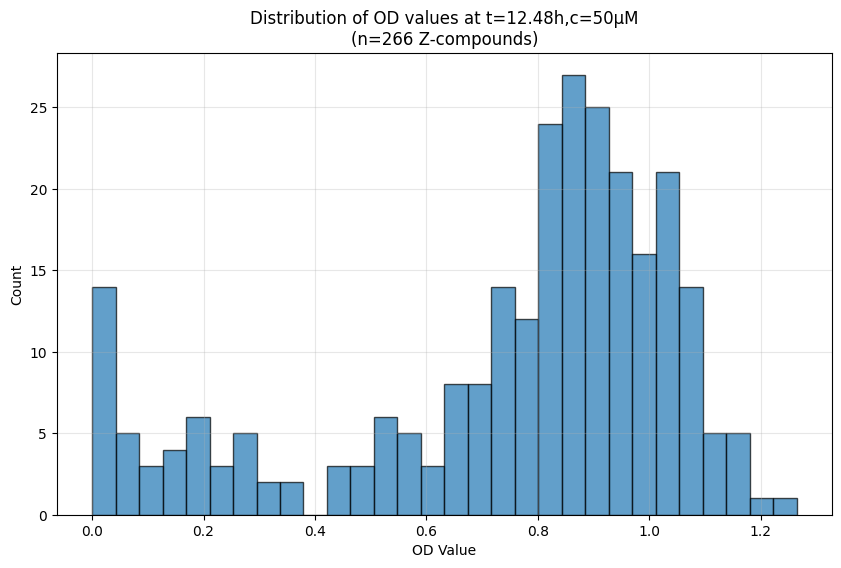

Z-compounds with OD at t=12.48h, c=50µM:266
Mean OD: 0.749
Min OD: 0.000, Max OD:1.265


In [4]:
import matplotlib.pyplot as plt
                                                              
z_compounds = [m for m in multi_conc if                     
m.compound.startswith('Z')]                                 
                                                            
od_values = [                                               
    m.pivot_od.loc[12.48, 50.0]
    for m in z_compounds
    if (12.48 in m.pivot_od.index) and (50.0 in
m.pivot_od.columns)                                         
]
                                                            
plt.figure(figsize=(10, 6))
plt.hist(od_values, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('OD Value')
plt.ylabel('Count')
plt.title(f'Distribution of OD values at t=12.48h,c=50µM\n(n={len(od_values)} Z-compounds)')                  
plt.grid(alpha=0.3)
plt.show()                                                  
                
print(f'Z-compounds with OD at t=12.48h, c=50µM:{len(od_values)}')
print(f'Mean OD: {sum(od_values)/len(od_values):.3f}')      
print(f'Min OD: {min(od_values):.3f}, Max OD:{max(od_values):.3f}')

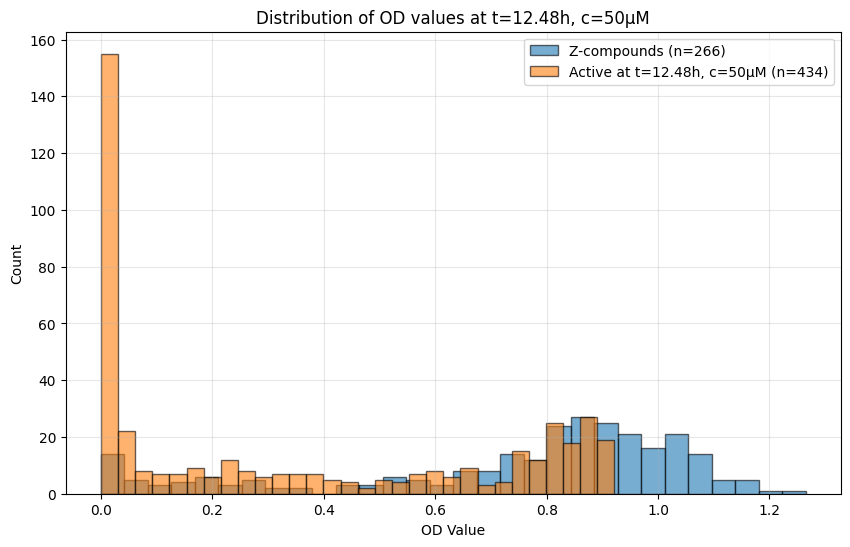

In [5]:
import matplotlib.pyplot as plt

  # Z-compounds
z_compounds = [m for m in multi_conc if m.compound.startswith('Z')]
z_od_values = [
    m.pivot_od.loc[12.48, 50.0]
    for m in z_compounds
    if (12.48 in m.pivot_od.index) and (50.0 in m.pivot_od.columns)
]

# Active compounds
active_at_point = [
    m for m in multi_conc
    if (12.48 in m.pivot_cls.index) and
    (50.0 in m.pivot_cls.columns) and
    (m.pivot_cls.loc[12.48, 50.0] == 1)
]
active_od_values = [
    m.pivot_od.loc[12.48, 50.0]
    for m in active_at_point
]

plt.figure(figsize=(10, 6))
plt.hist(z_od_values, bins=30, alpha=0.6, label=f'Z-compounds (n={len(z_od_values)})',
edgecolor='black')
plt.hist(active_od_values, bins=30, alpha=0.6, label=f'Active at t=12.48h, c=50µM (n={len(active_od_values)})', edgecolor='black')
plt.xlabel('OD Value')
plt.ylabel('Count')
plt.title('Distribution of OD values at t=12.48h, c=50µM')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
z_active_at_12_50 = sum(                                    
      1 for m in multi_conc                                   
      if m.compound.startswith('Z') and                       
      (12.48 in m.pivot_cls.index) and                        
      (50.0 in m.pivot_cls.columns) and                       
      (m.pivot_cls.loc[12.48, 50.0] == 1)                     
  )
                                                              
print(f'Z-compounds active at t=12.48h, c=50µM:{z_active_at_12_50}')

Z-compounds active at t=12.48h, c=50µM:19


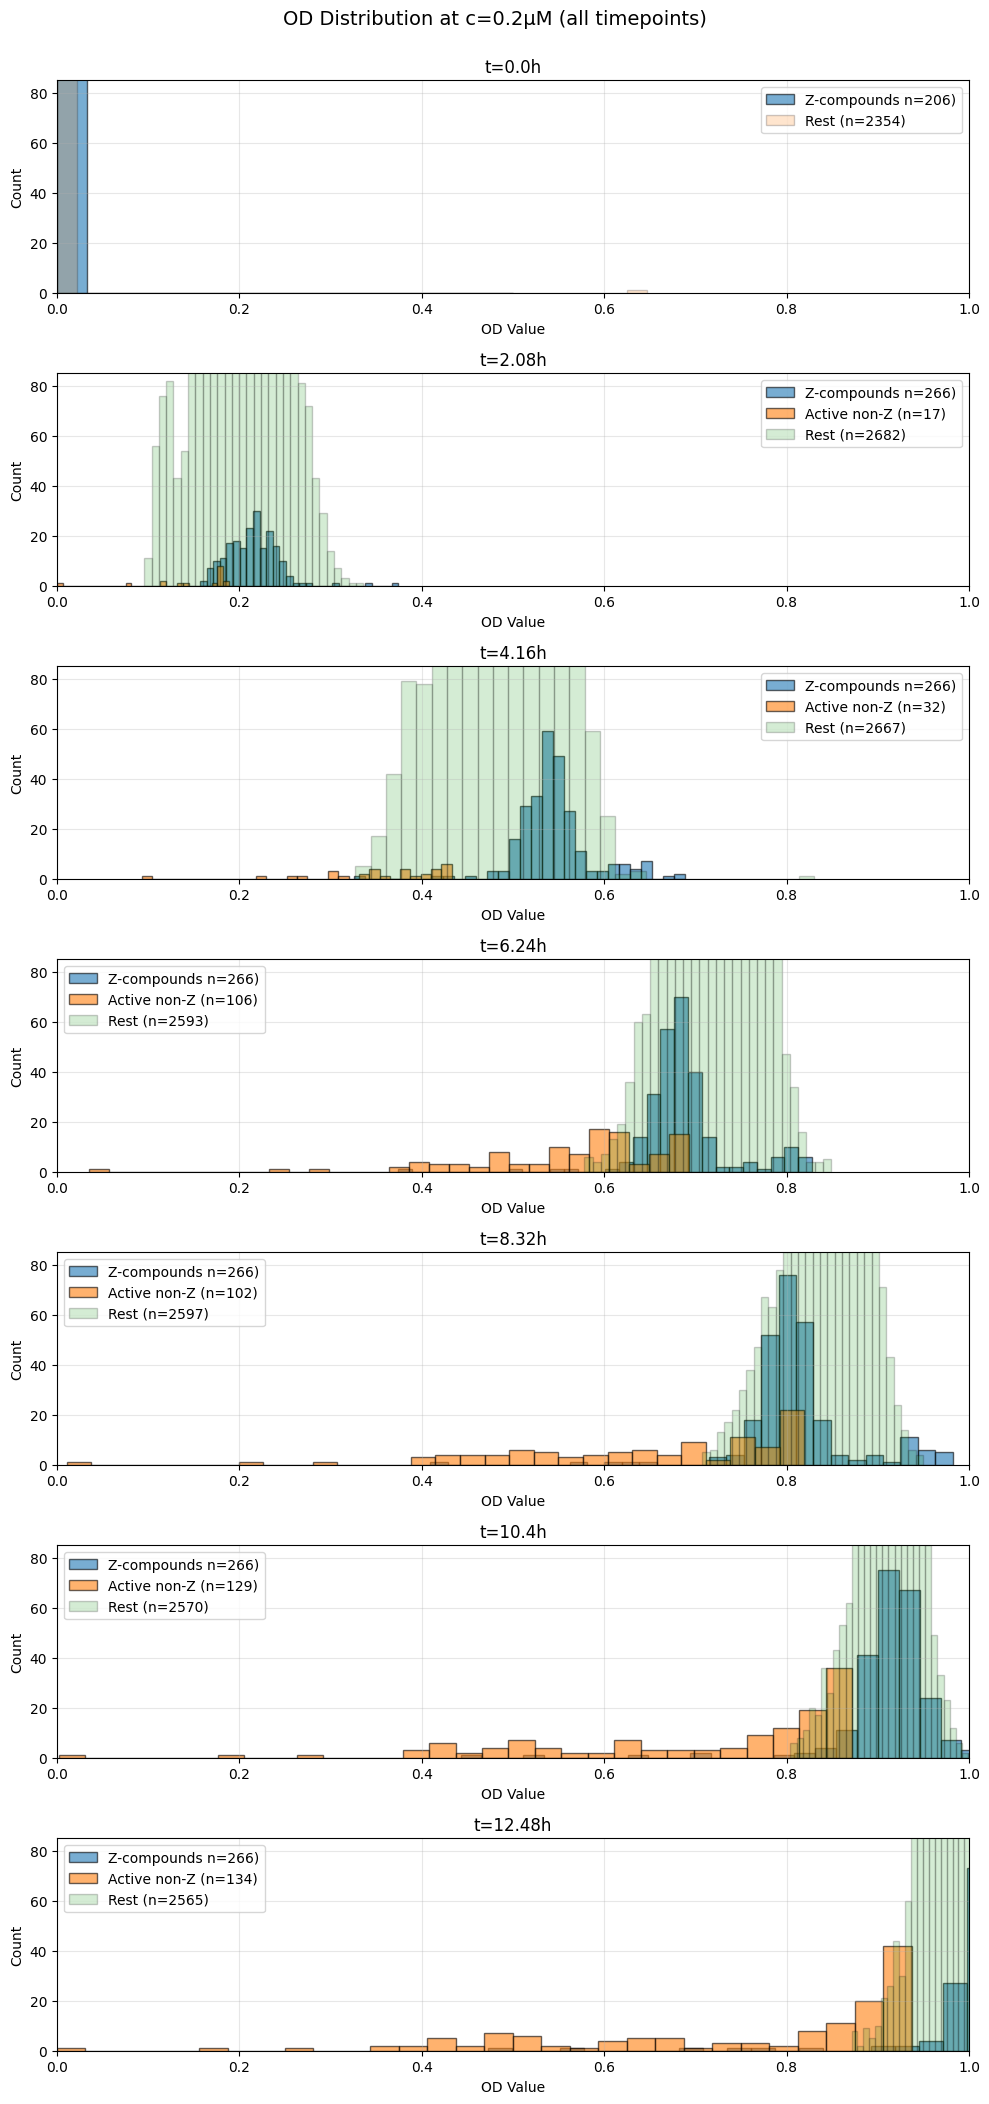

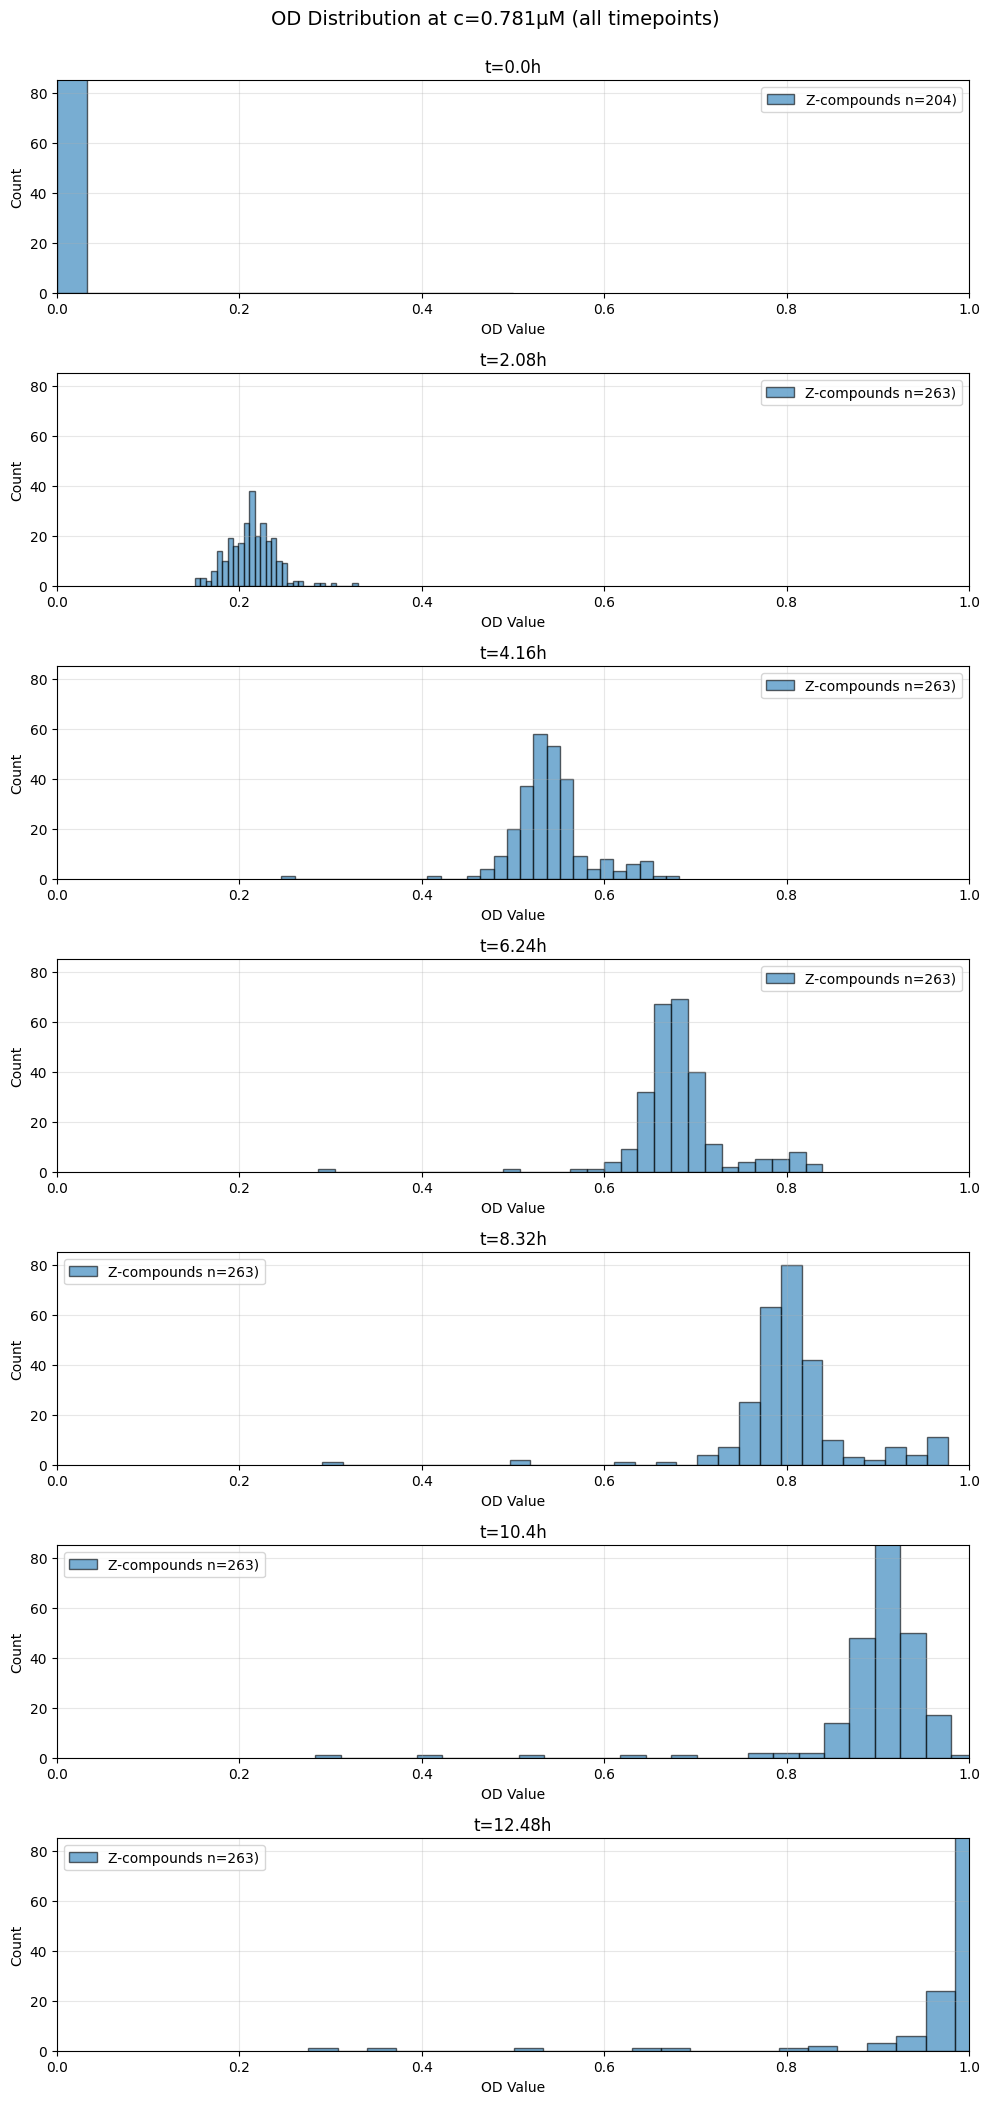

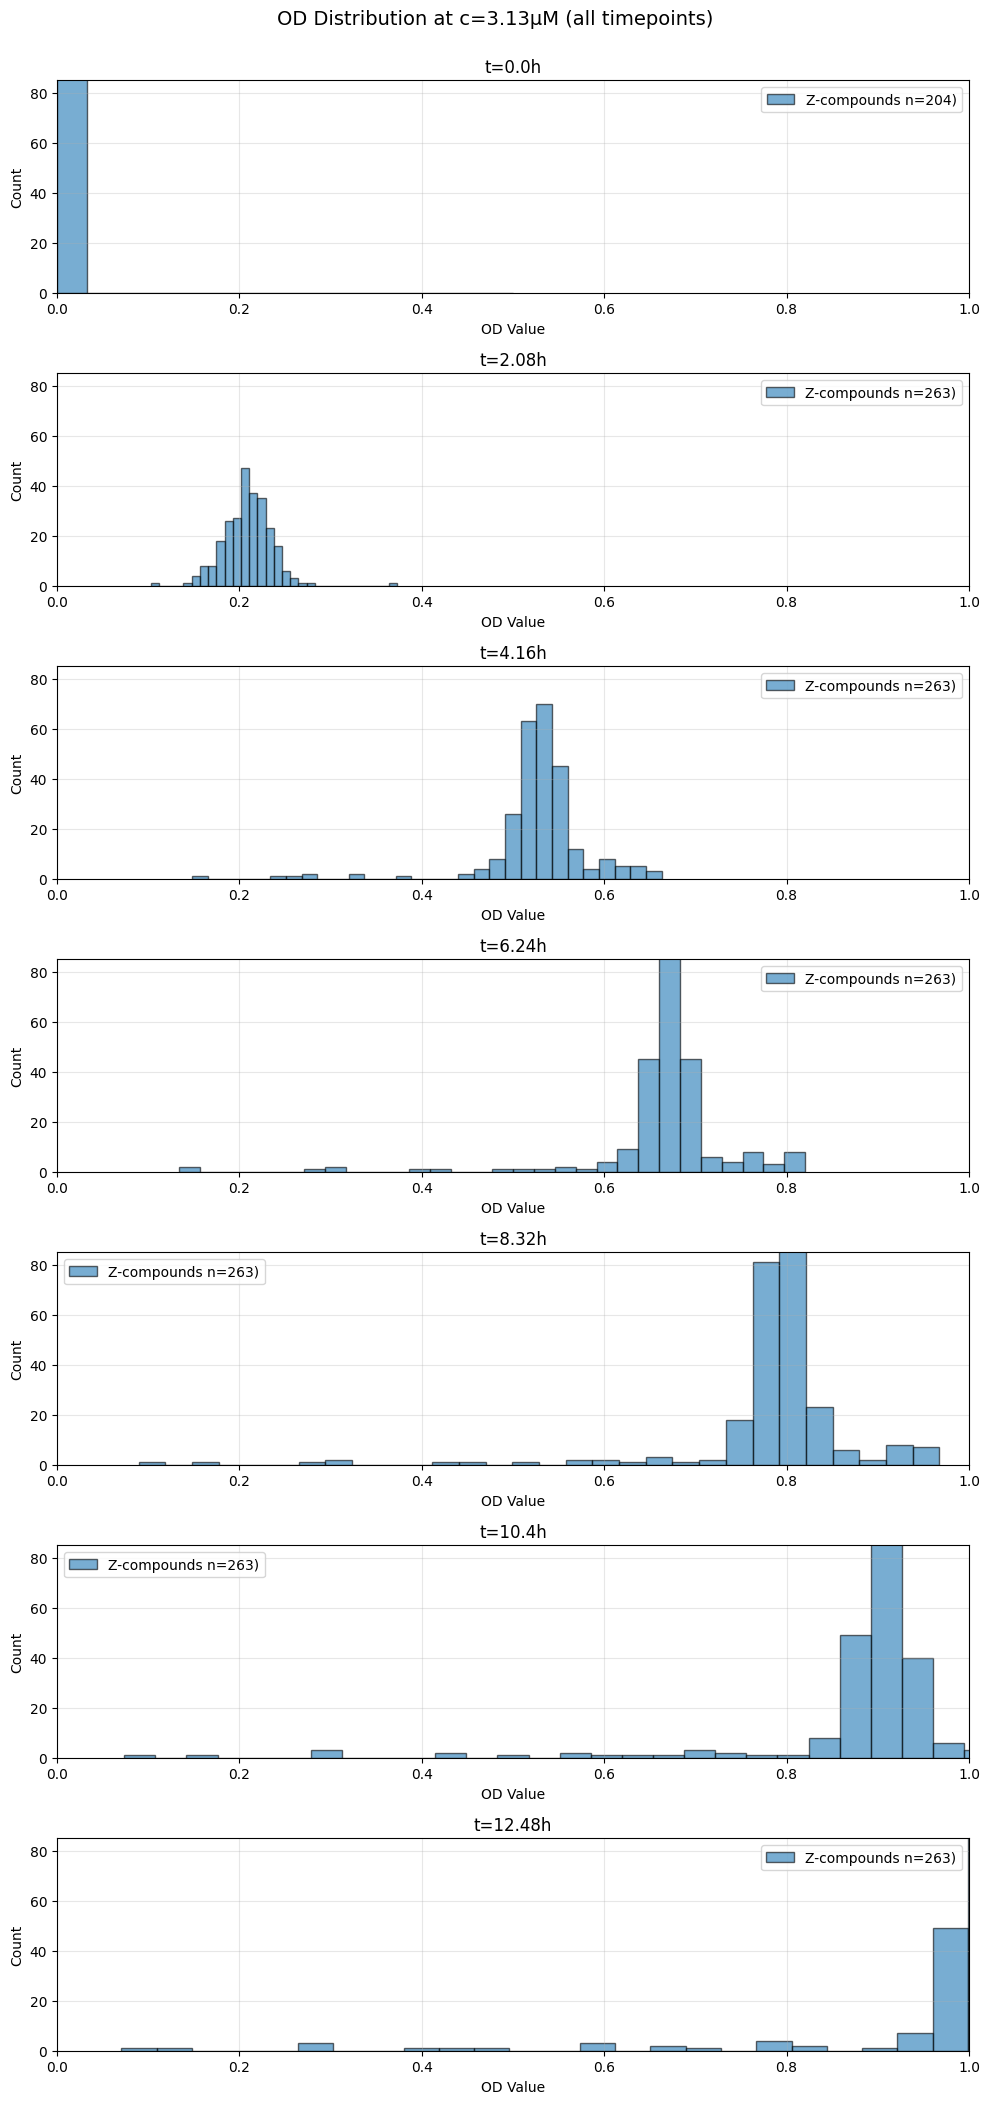

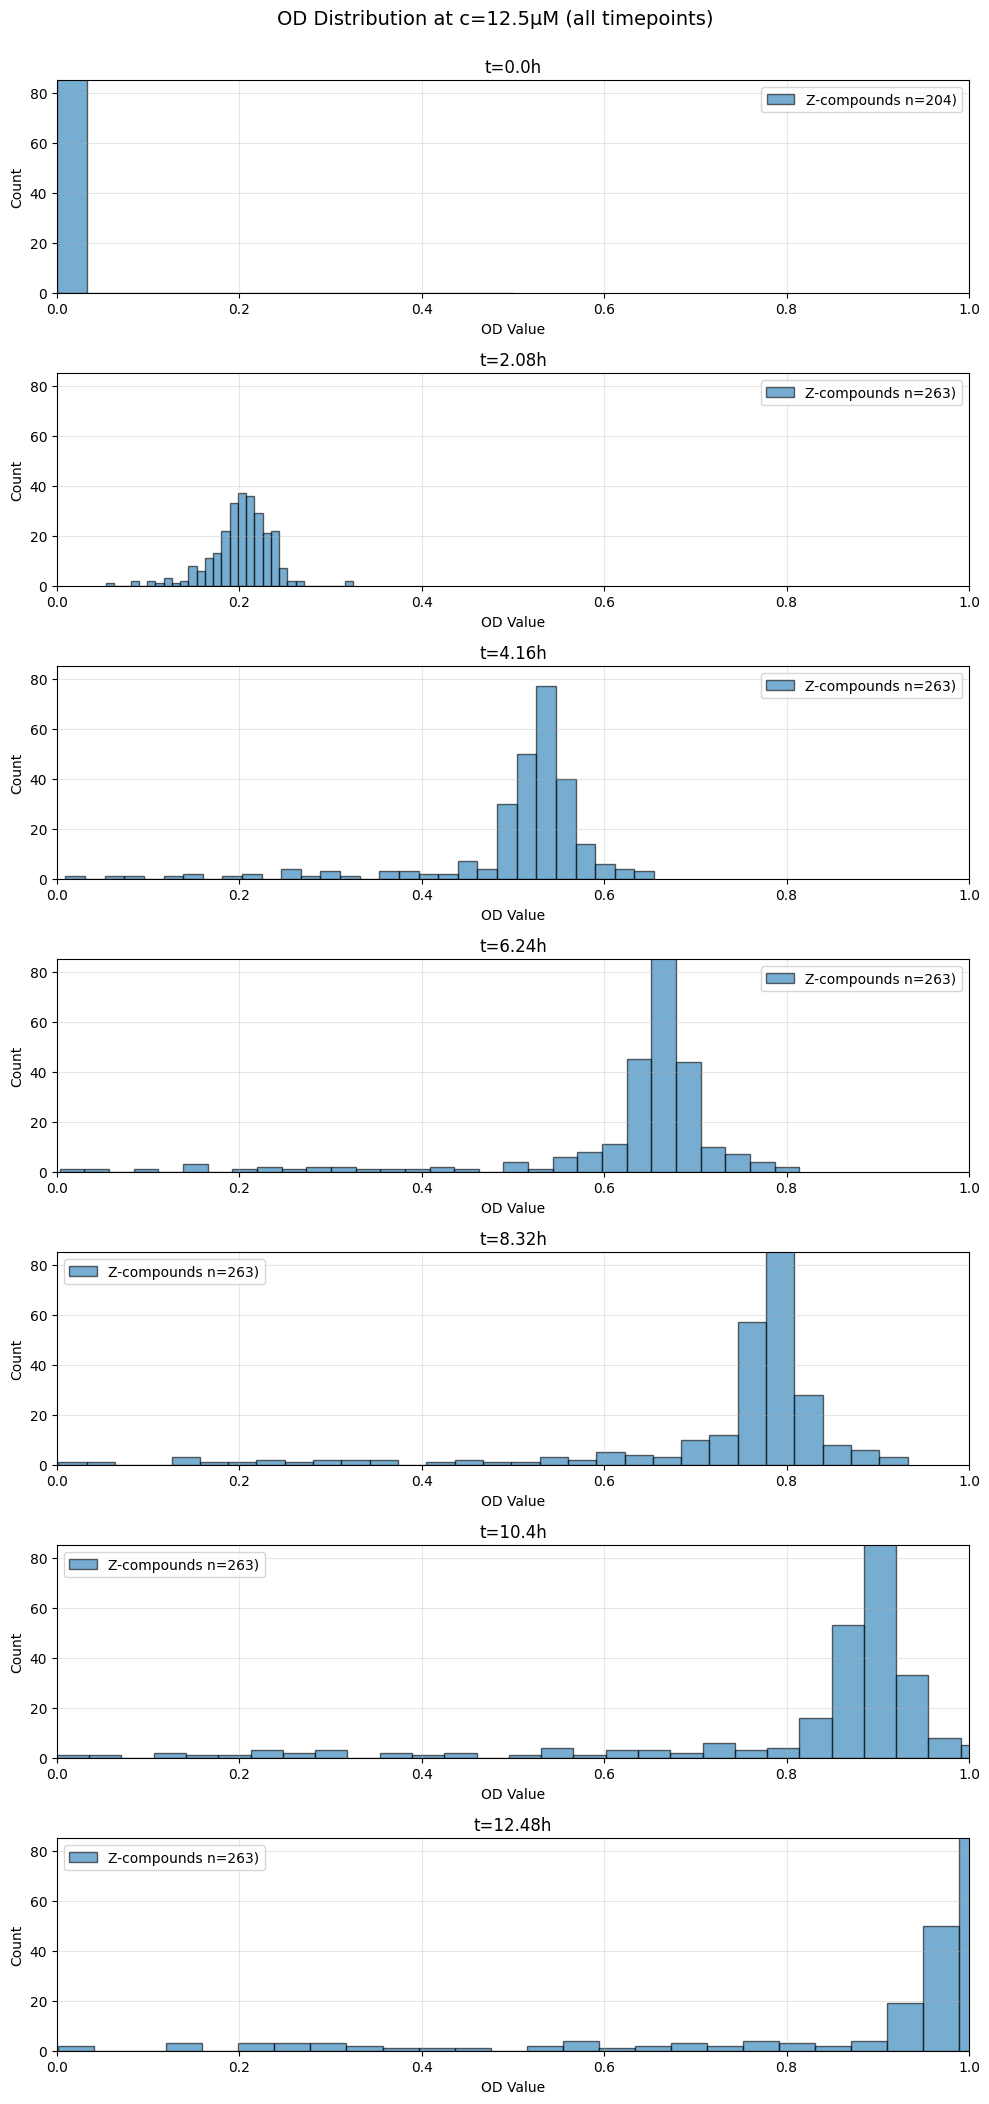

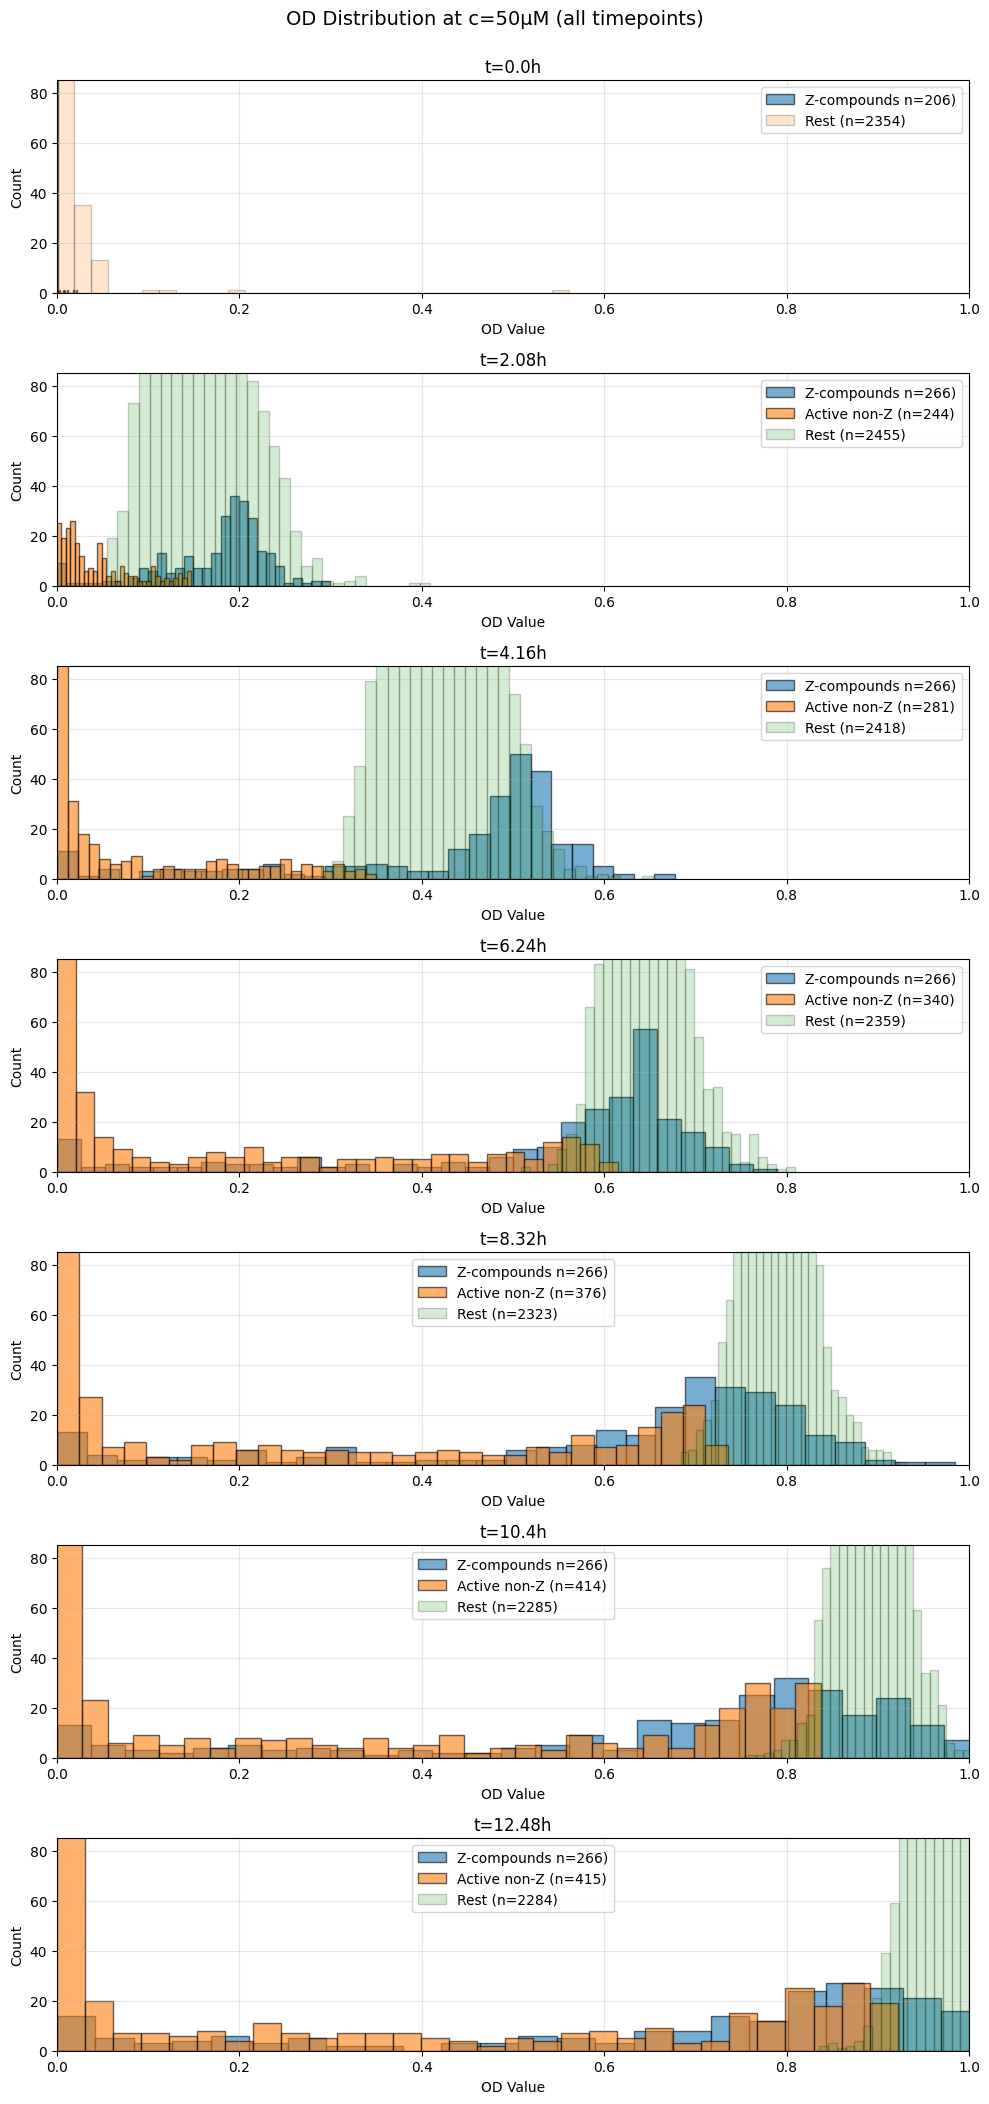

In [15]:
import matplotlib.pyplot as plt                                                           

# Get all unique times and concentrations                                                 
times = set()   
concs = set()
for m in multi_conc:
    times.update(m.pivot_cls.index)
    concs.update(m.pivot_cls.columns)
                                                                                        
times = sorted(times)
concs = sorted(concs)                                                                     
                
# Loop through each concentration
for c in [0.2, 0.781, 3.13, 12.5, 50]:
    fig, axes = plt.subplots(len(times), 1, figsize=(10, 3*len(times)))
    if len(times) == 1:                                                                   
        axes = [axes]  # Handle single subplot case
                                                                                        
    for i, t in enumerate(times):                                                         
        # Categorize compounds: Z-compounds, active non-Z, and rest
        z_od_values = []                                                                  
        active_non_z_od_values = []
        rest_od_values = []

        for m in multi_conc:                                                              
            # Check if this compound has data at (t,c)
            if (t not in m.pivot_od.index) or (c not in m.pivot_od.columns):              
                continue

            od_value = m.pivot_od.loc[t, c]                                               
            is_z = m.compound.startswith('Z')
            is_active = (t in m.pivot_cls.index) and (c in m.pivot_cls.columns) and (m.pivot_cls.loc[t, c] == 1)                                                              

            # Mutually exclusive categorization                                           
            if is_z:
                z_od_values.append(od_value)
            elif is_active:
                active_non_z_od_values.append(od_value)
            else:                                                                         
                rest_od_values.append(od_value)
                                                                                        
        # Plot on current subplot
        ax = axes[i]
        if z_od_values:
            ax.hist(z_od_values, bins=30, alpha=0.6, label=f'Z-compounds n={len(z_od_values)})', edgecolor='black')                                               
        if active_non_z_od_values:
            ax.hist(active_non_z_od_values, bins=30, alpha=0.6, label=f'Active non-Z (n={len(active_non_z_od_values)})', edgecolor='black')                                    
        if rest_od_values:
            ax.hist(rest_od_values, bins=30, alpha=0.2, label=f'Rest (n={len(rest_od_values)})', edgecolor='black')                                            

        ax.set_xlim(0, 1)
        ax.set_ylim(0,85)                                                                 
        ax.set_xlabel('OD Value')
        ax.set_ylabel('Count')
        ax.set_title(f't={t}h')                                                           
        ax.legend()
        ax.grid(alpha=0.3)                                                                
                
    fig.suptitle(f'OD Distribution at c={c}µM (all timepoints)', fontsize=14, y=1.00)     
    plt.tight_layout()
    plt.show() 

In [ ]:
count = sum(1 for m in multi_conc if m.compound.startswith('Z'))                                   
print(count) 

0


In [3]:
active_at_point = sum(
    (12.48 in m.pivot_cls.index) and
    (50.0 in m.pivot_cls.columns) and
    (m.pivot_cls.loc[12.48, 50.0] == 1)
    for m in multi_conc
)
any_active = sum(bool(m.pivot_cls.values.any()) for m in multi_conc)

print(f'Active at t=12.48h, c=50µM : {active_at_point} ({100*active_at_point/len(multi_conc):.1f}%)')
print(f'At least one active cell   : {any_active} ({100*any_active/len(multi_conc):.1f}%)')

Active at t=12.48h, c=50µM : 434 (14.6%)
At least one active cell   : 1014 (34.2%)


In [4]:
missing = [                                                                            
      m for m in multi_conc                                                            
      if (12.48 not in m.pivot_cls.index) or (50.0 not in m.pivot_cls.columns)           
  ]                                                                                      
print(f'Missing t=12.48 or c=50: {len(missing)} / {len(multi_conc)}')  

Missing t=12.48 or c=50: 0 / 2965


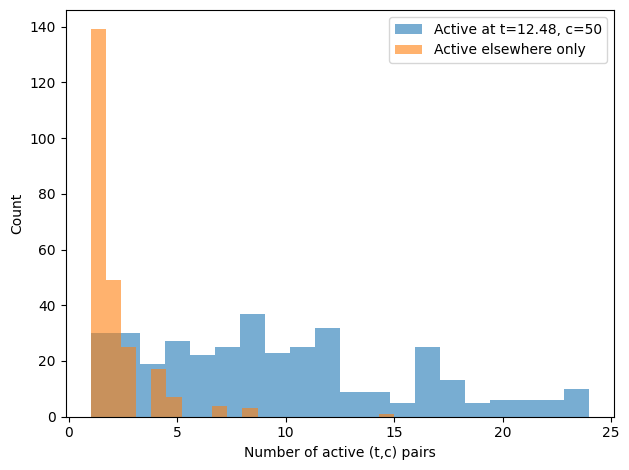

In [5]:
import matplotlib.pyplot as plt                                                        
                                                                                       
active_at_point_counts = [                                                             
    m.pivot_cls.values.sum()
    for m in multi_conc                                                                
    if (12.48 in m.pivot_cls.index) and                                                
        (50.0 in m.pivot_cls.columns) and                                               
        (m.pivot_cls.loc[12.48, 50.0] == 1)                                             
]                                                                                      
                                                        
not_at_point_counts = [                                                                
    m.pivot_cls.values.sum()
    for m in multi_conc                                                                
    if bool(m.pivot_cls.values.any()) and not (           
        (12.48 in m.pivot_cls.index) and                                               
        (50.0 in m.pivot_cls.columns) and
        (m.pivot_cls.loc[12.48, 50.0] == 1)                                            
    )                                                                                  
]
                                                                                        
fig, ax = plt.subplots()                                  
ax.hist(active_at_point_counts, bins=20, alpha=0.6, label='Active at t=12.48, c=50')
ax.hist(not_at_point_counts, bins=20, alpha=0.6, label='Active elsewhere only')        
ax.set_xlabel('Number of active (t,c) pairs')
ax.set_ylabel('Count')                                                                 
ax.legend()                                               
plt.tight_layout()                                                                     
plt.show()                                                
               

In [15]:
for n in range(1, 16):
    count = sum(
        1 for m in multi_conc                               
        if m.pivot_cls.values.sum() >= n and not (          
            (12.48 in m.pivot_cls.index) and                
            (50.0 in m.pivot_cls.columns) and               
            (m.pivot_cls.loc[12.48, 50.0] == 1)             
        )
    )                                                       
    print(f"n={n}: {count} compounds") 

n=1: 245 compounds
n=2: 106 compounds
n=3: 57 compounds
n=4: 32 compounds
n=5: 15 compounds
n=6: 8 compounds
n=7: 8 compounds
n=8: 4 compounds
n=9: 1 compounds
n=10: 1 compounds
n=11: 1 compounds
n=12: 1 compounds
n=13: 1 compounds
n=14: 1 compounds
n=15: 1 compounds


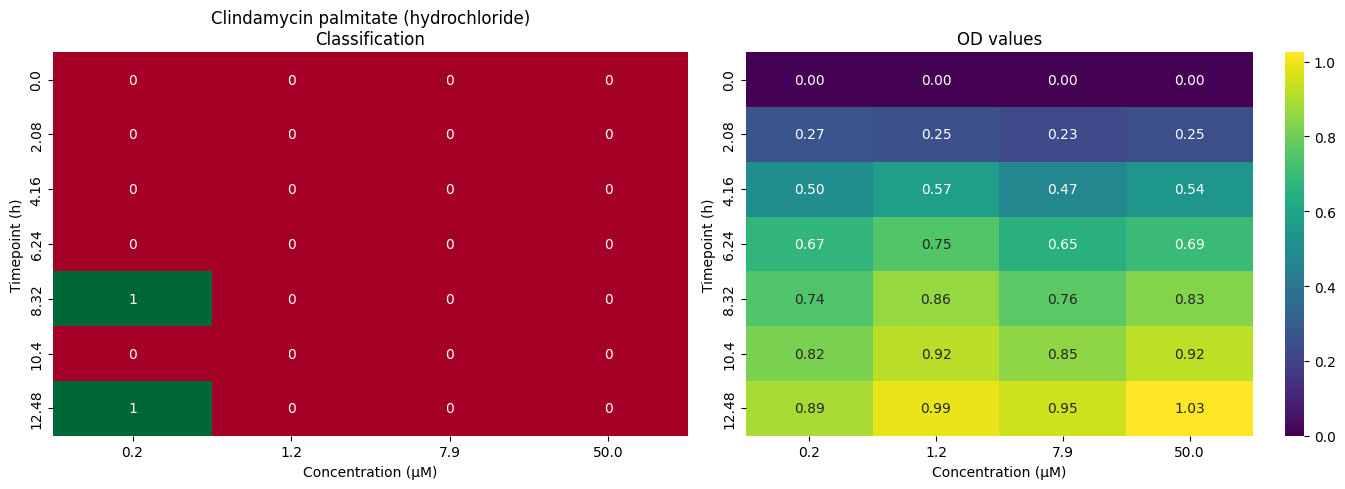

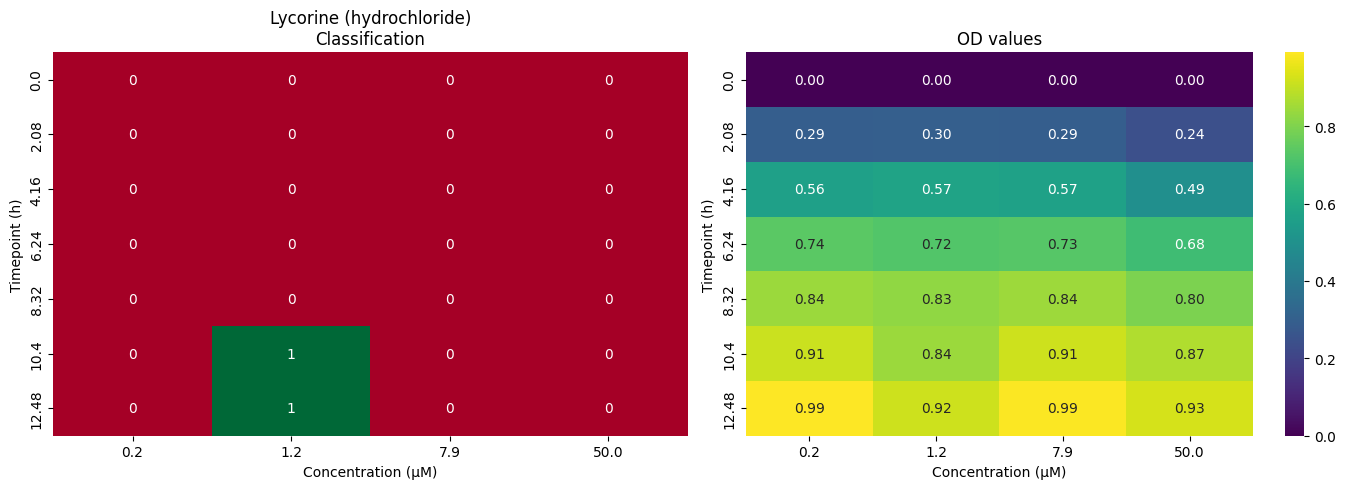

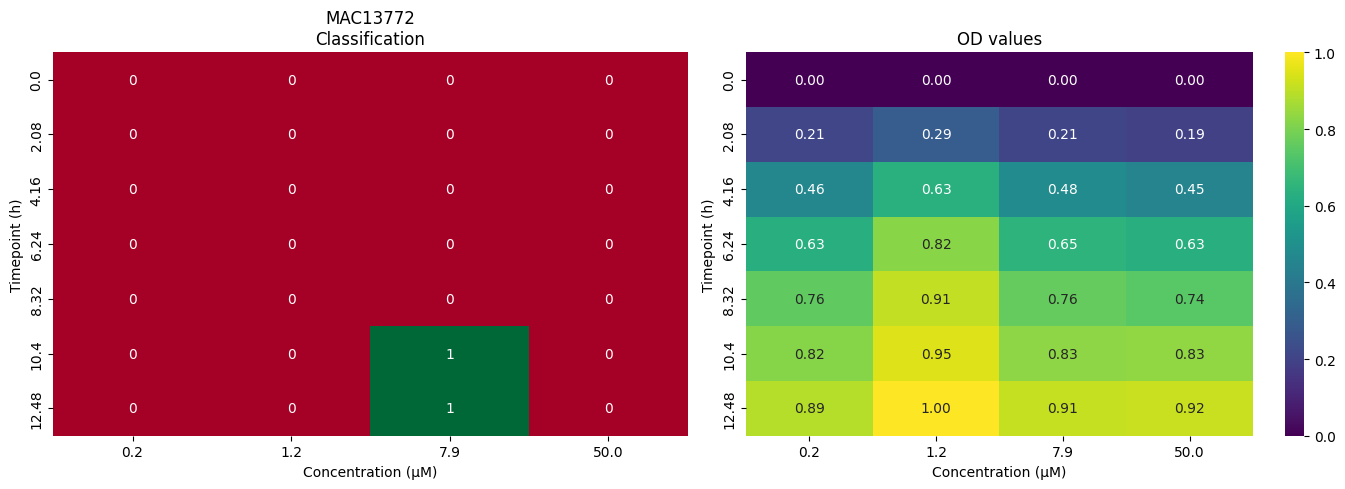

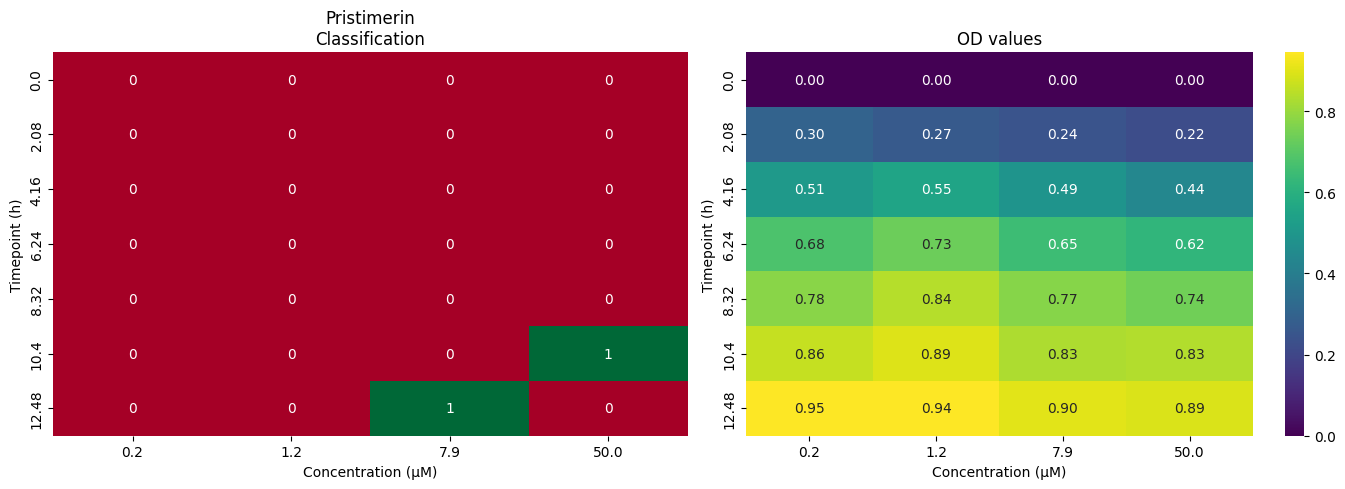

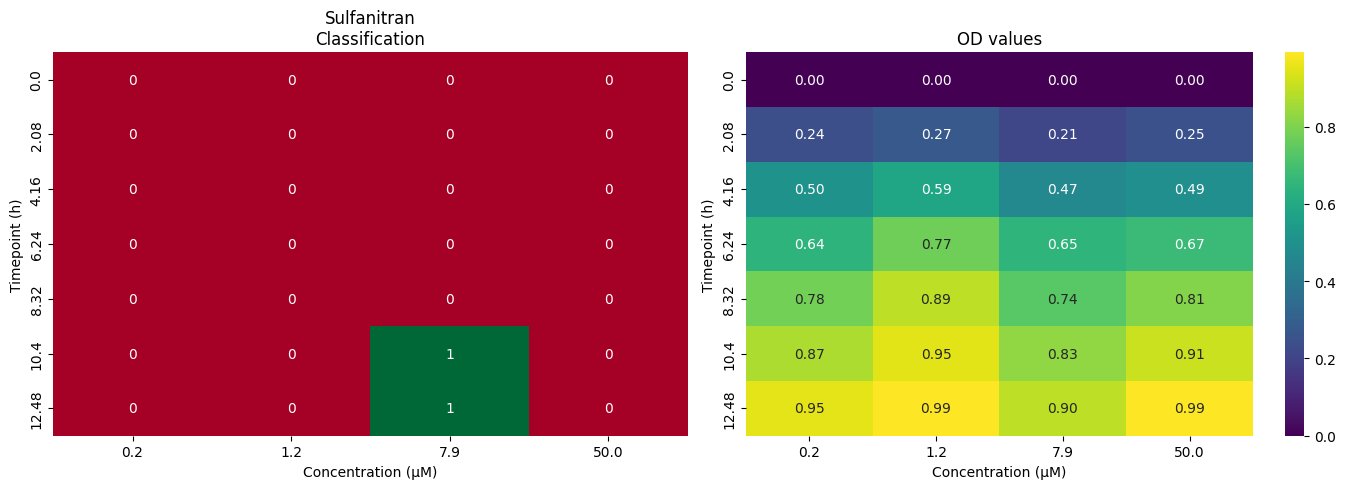

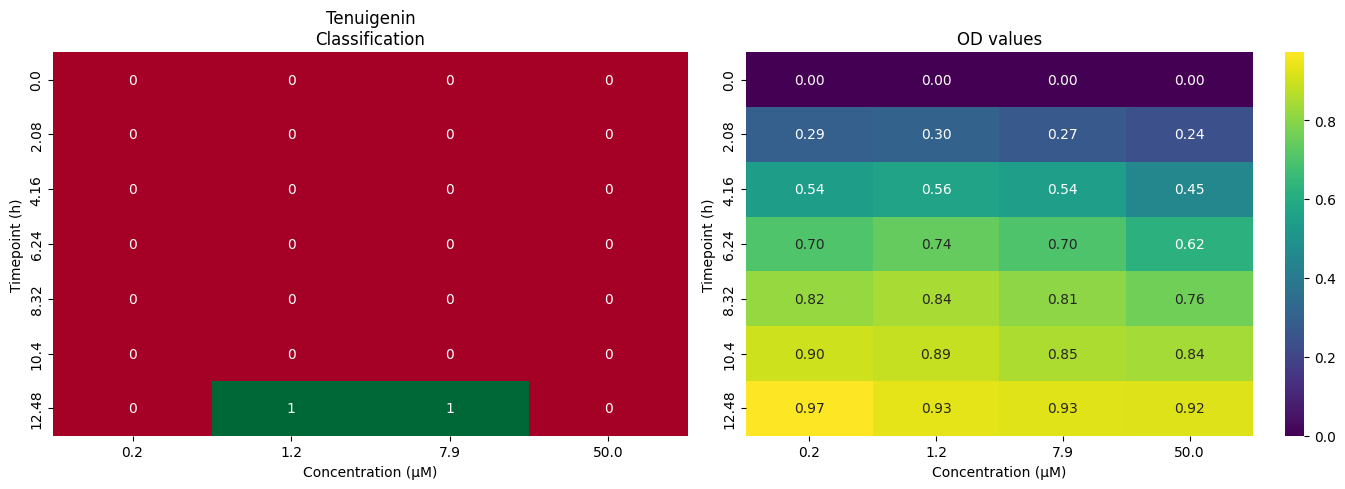

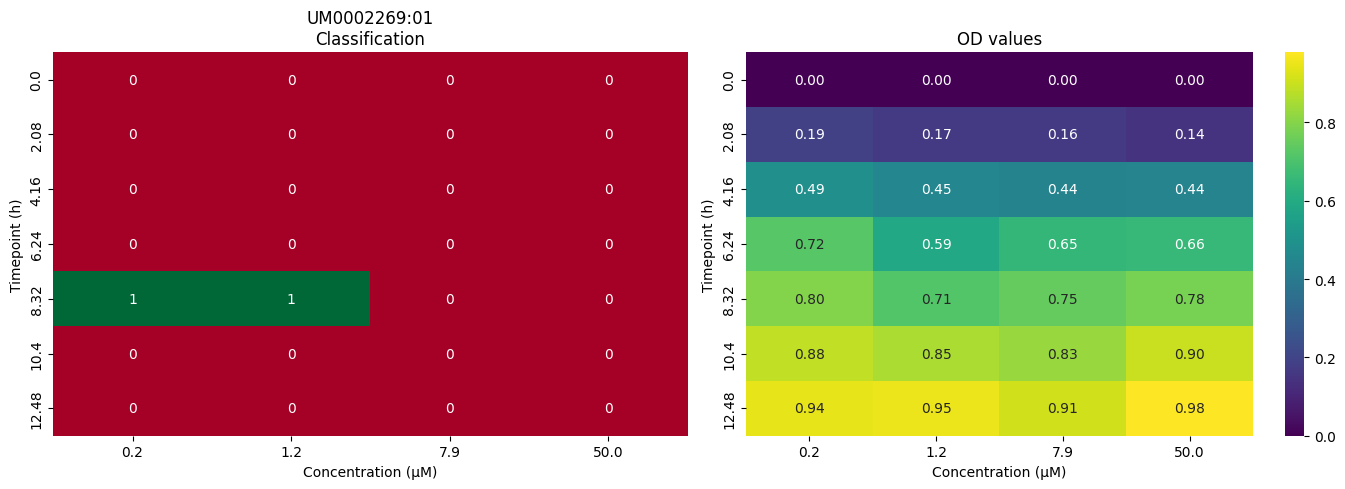

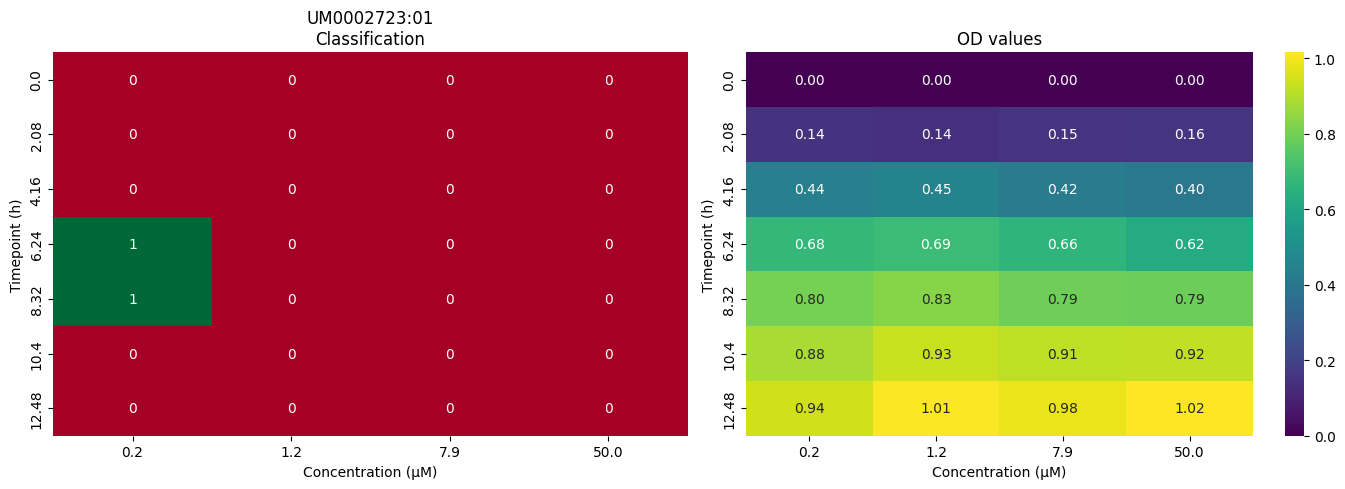

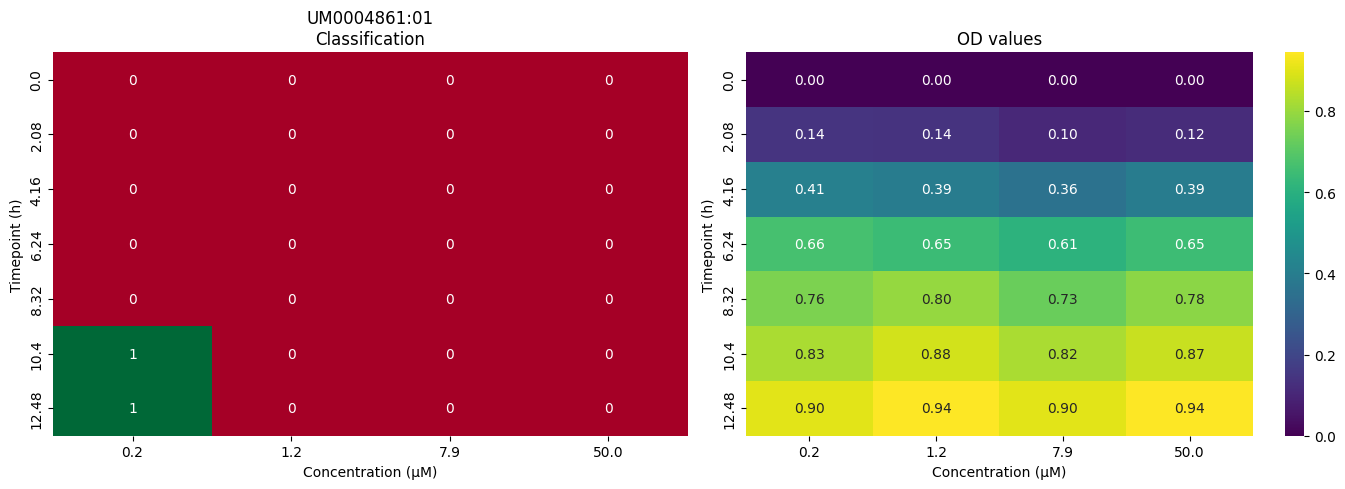

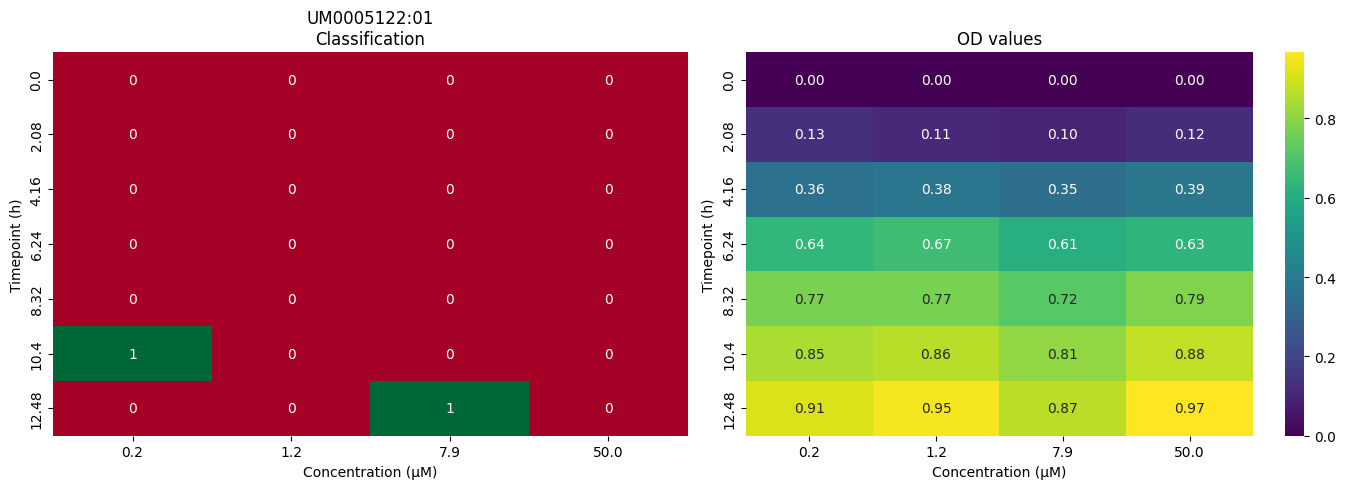

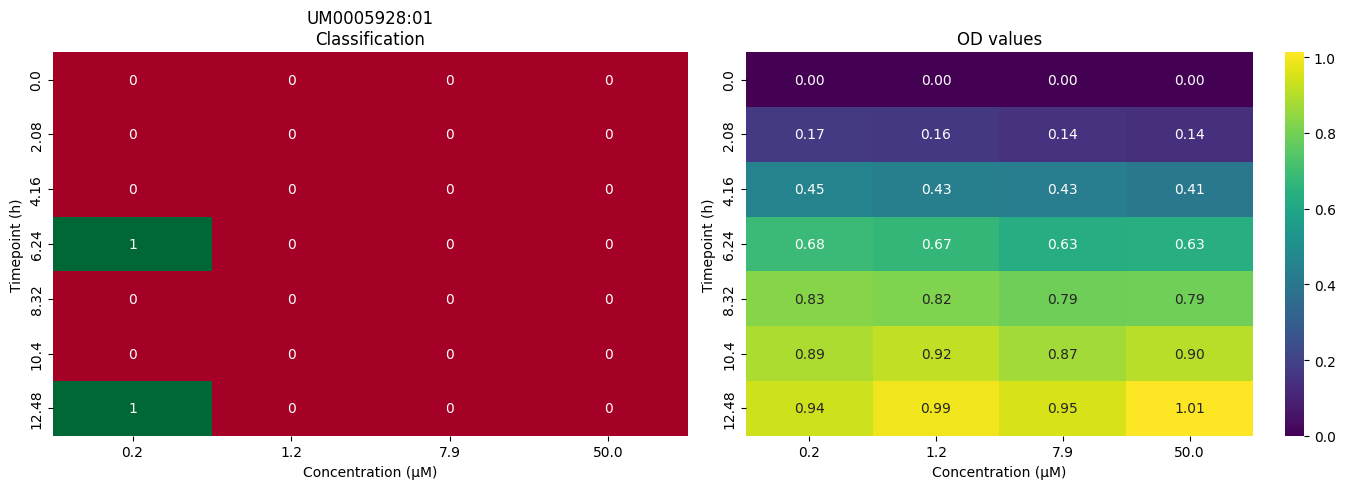

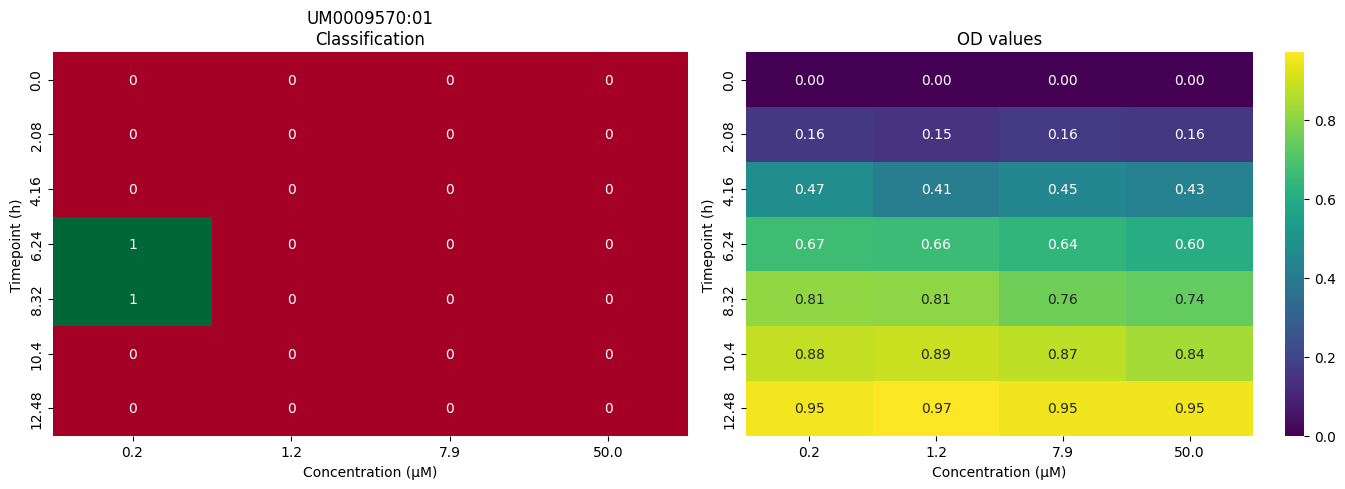

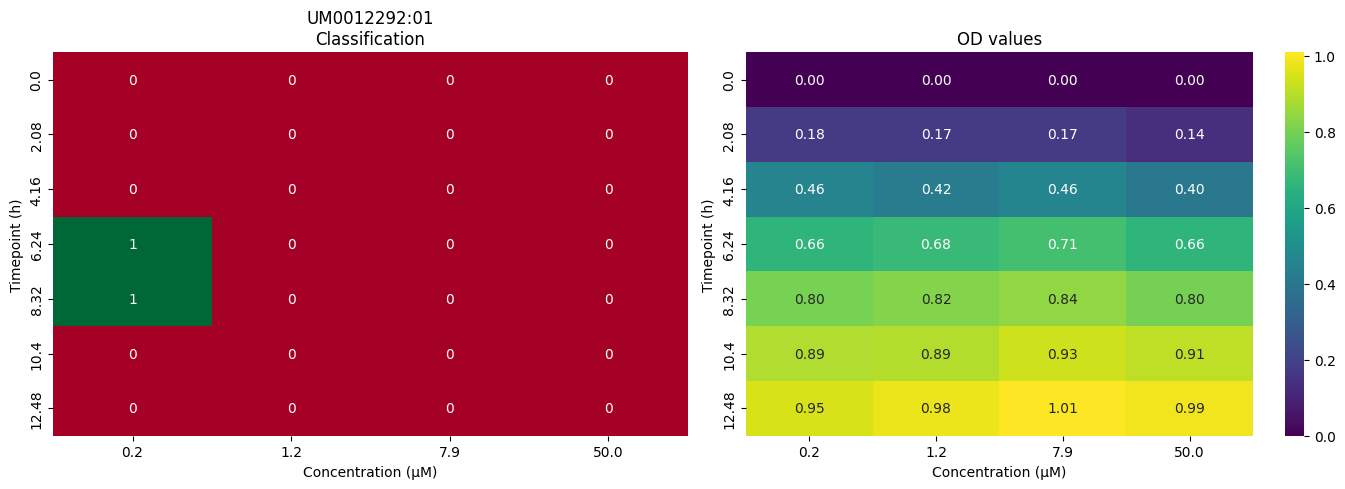

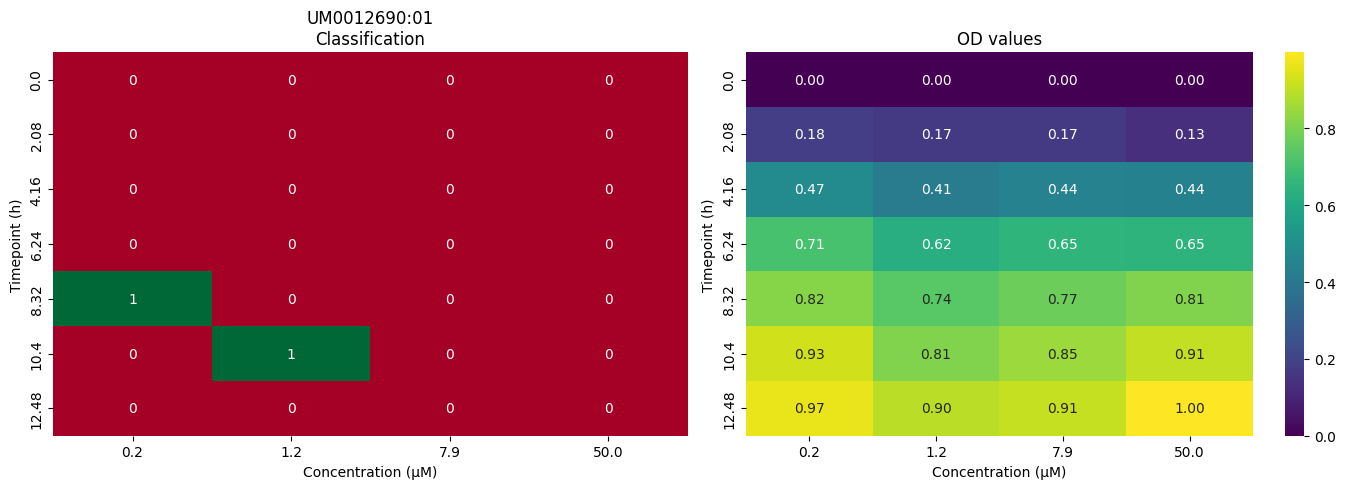

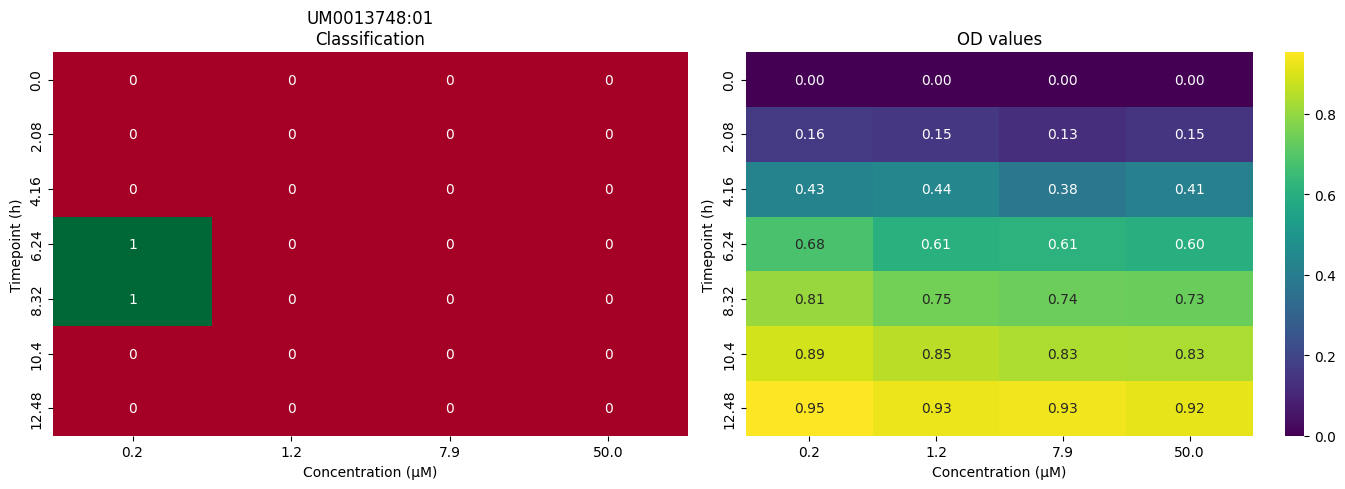

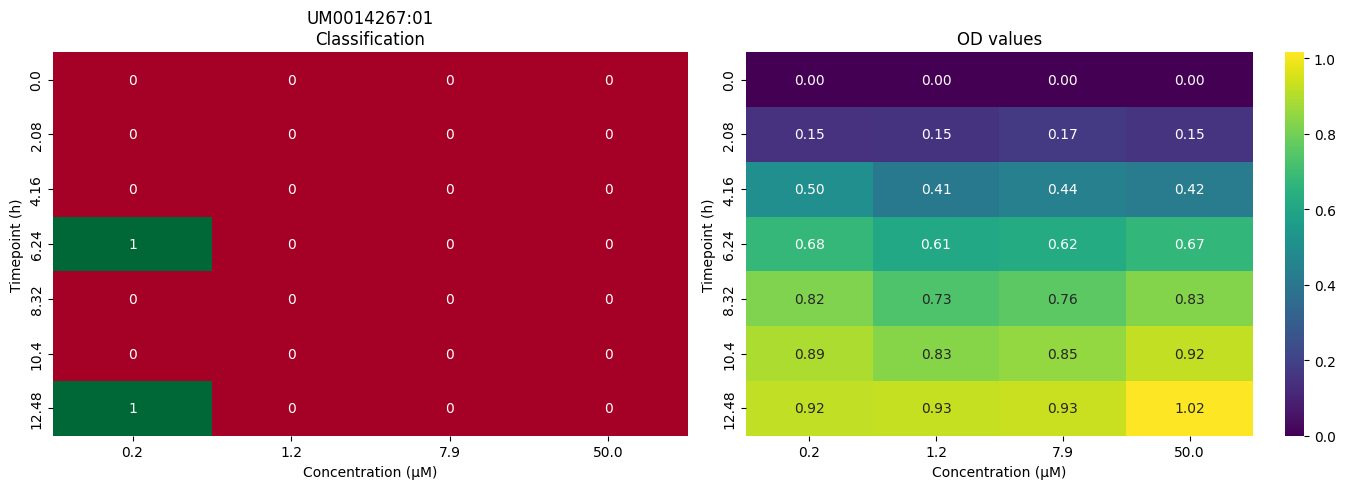

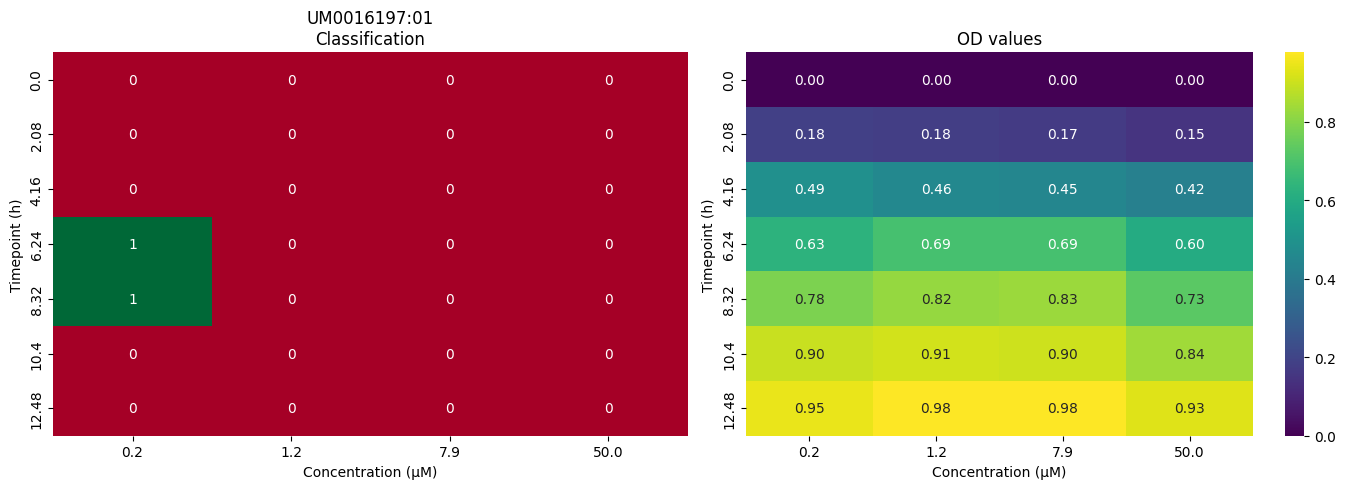

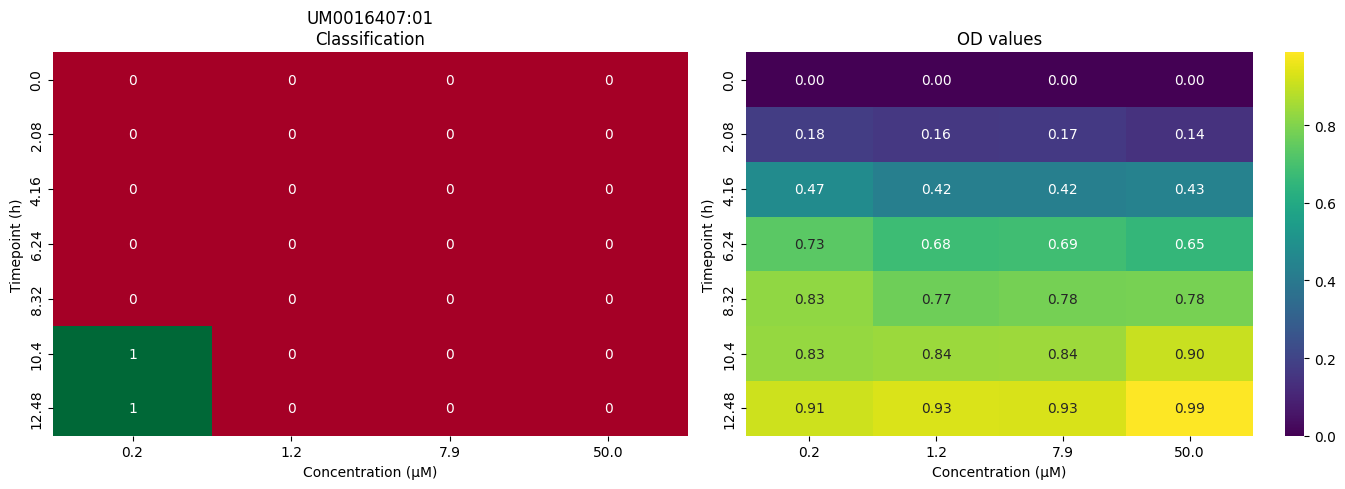

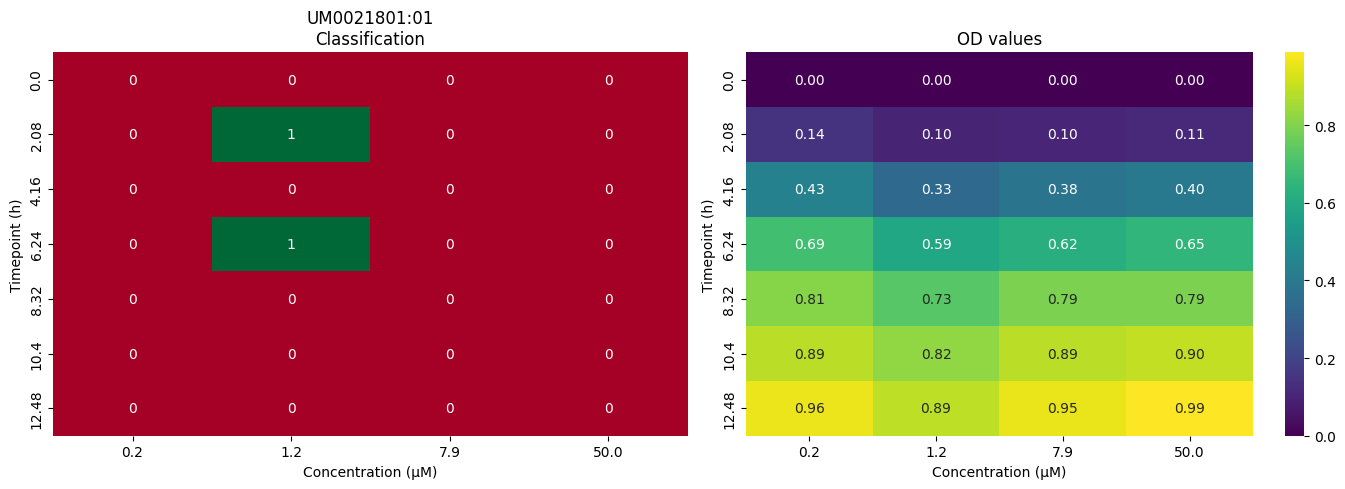

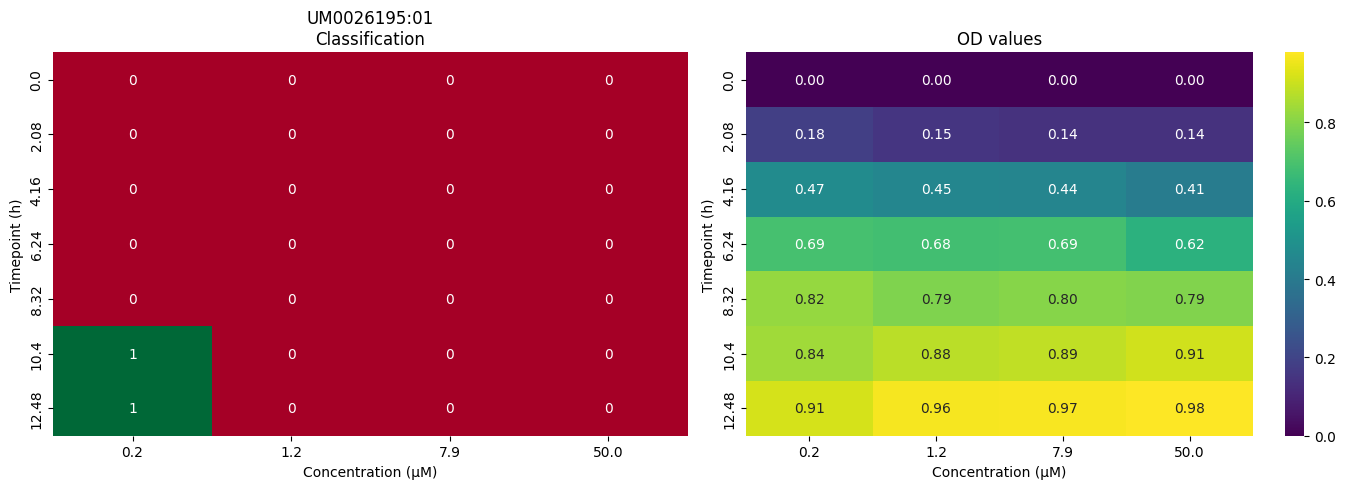

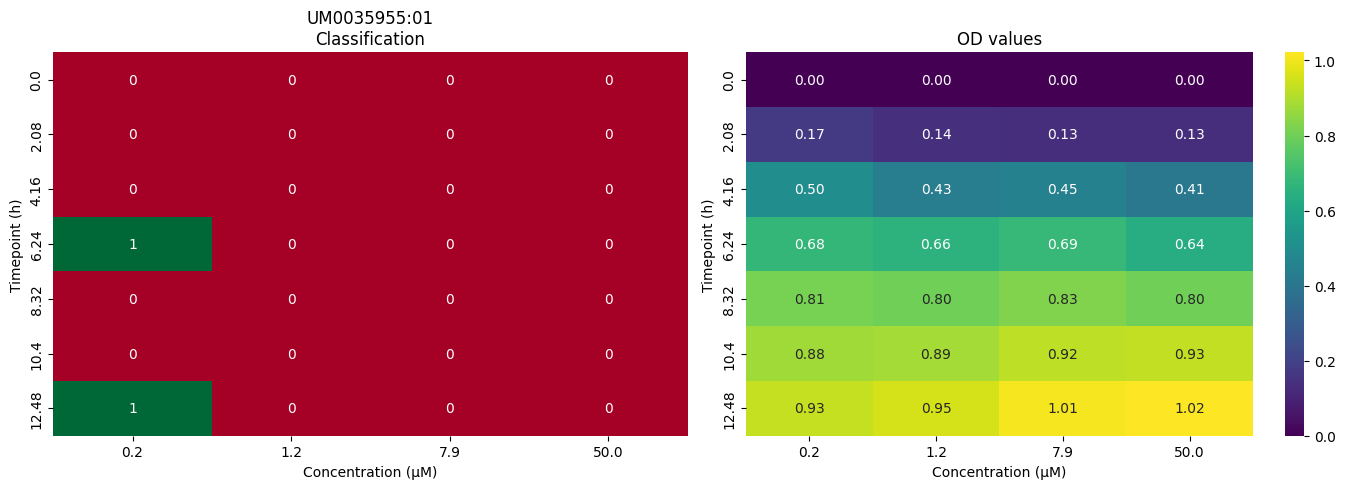

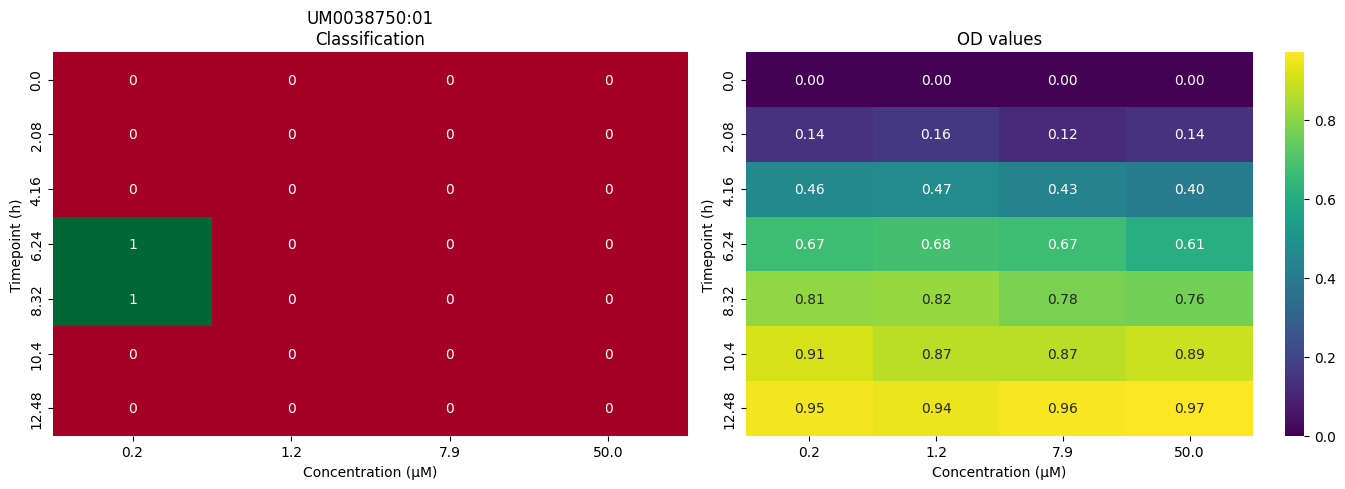

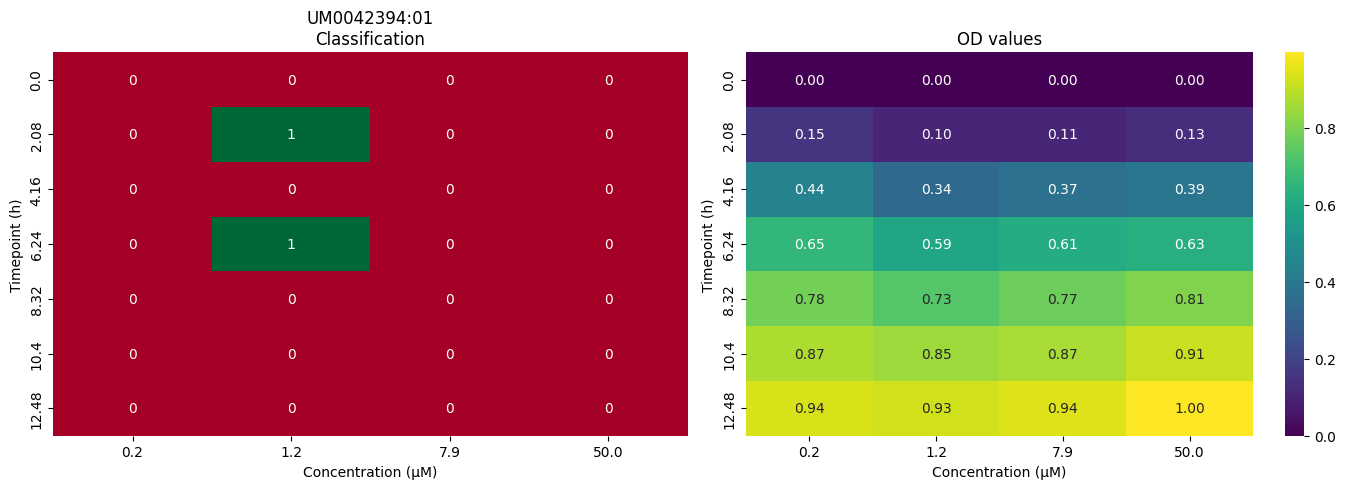

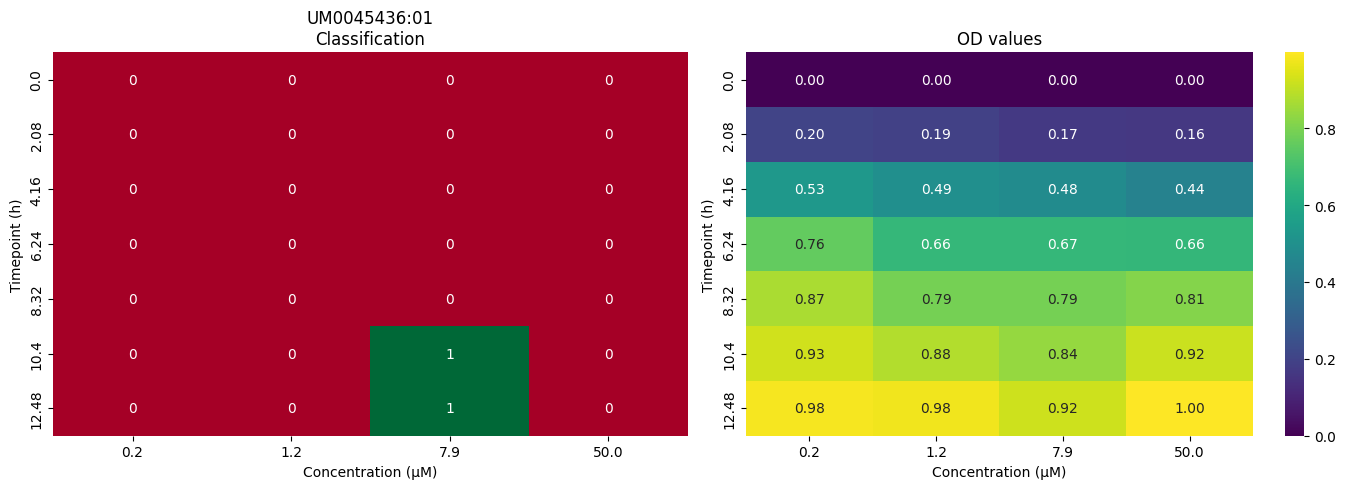

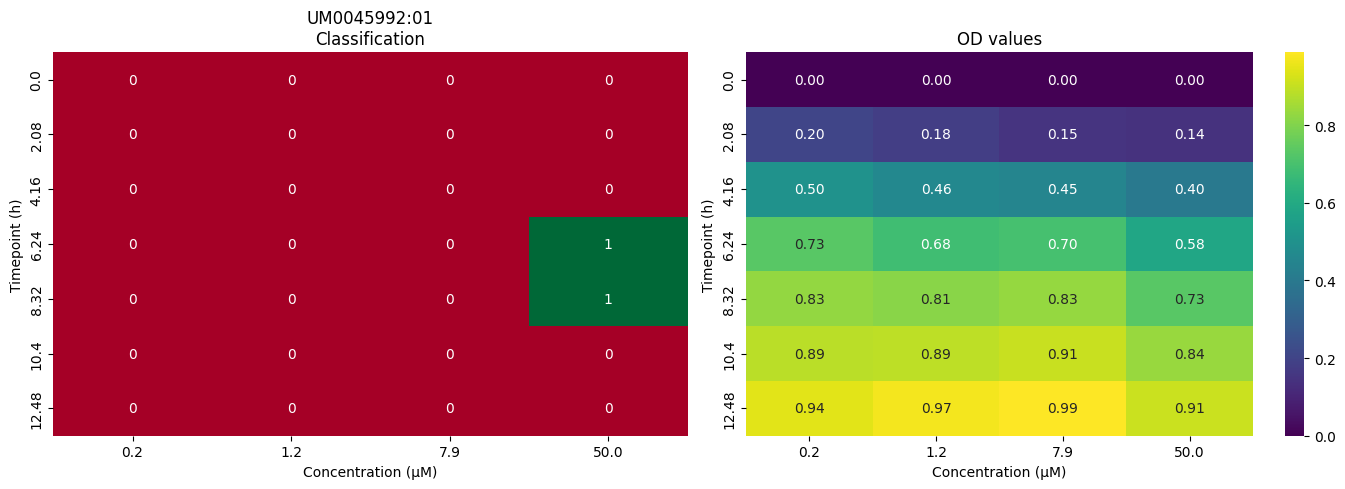

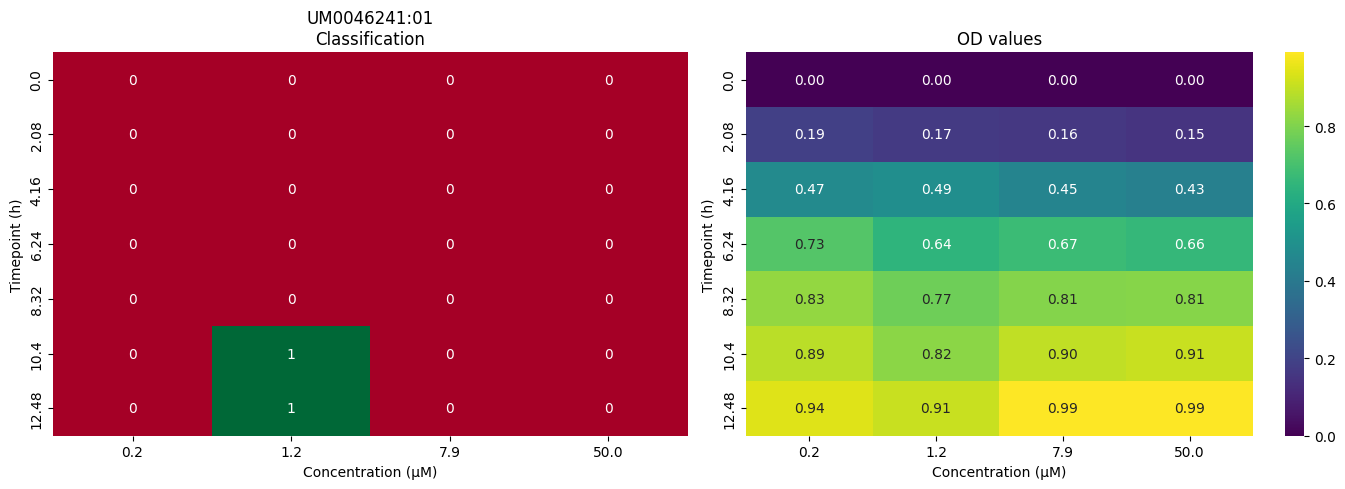

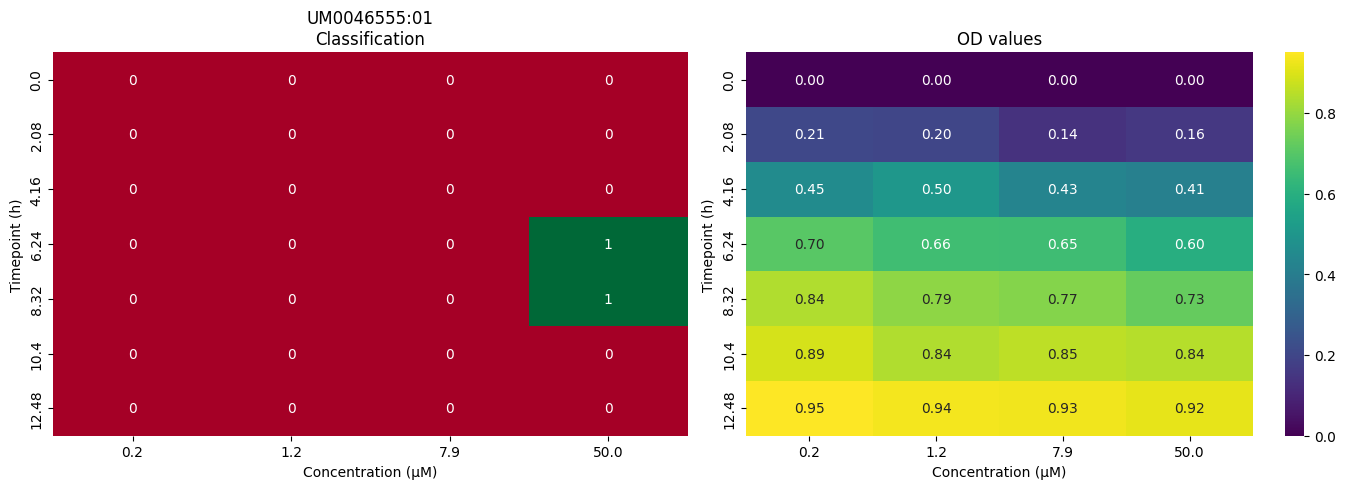

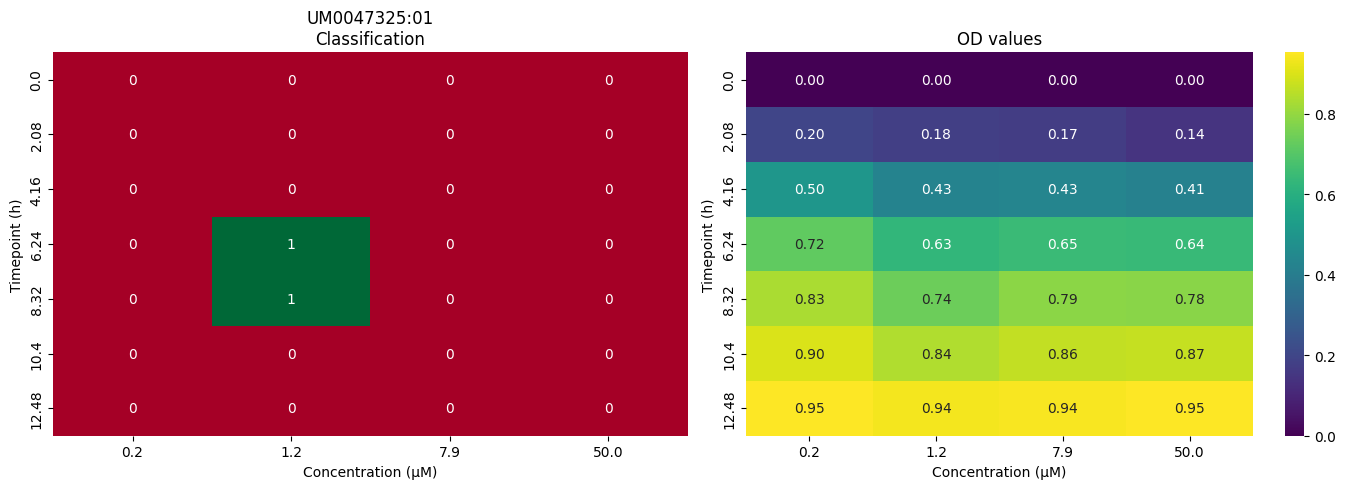

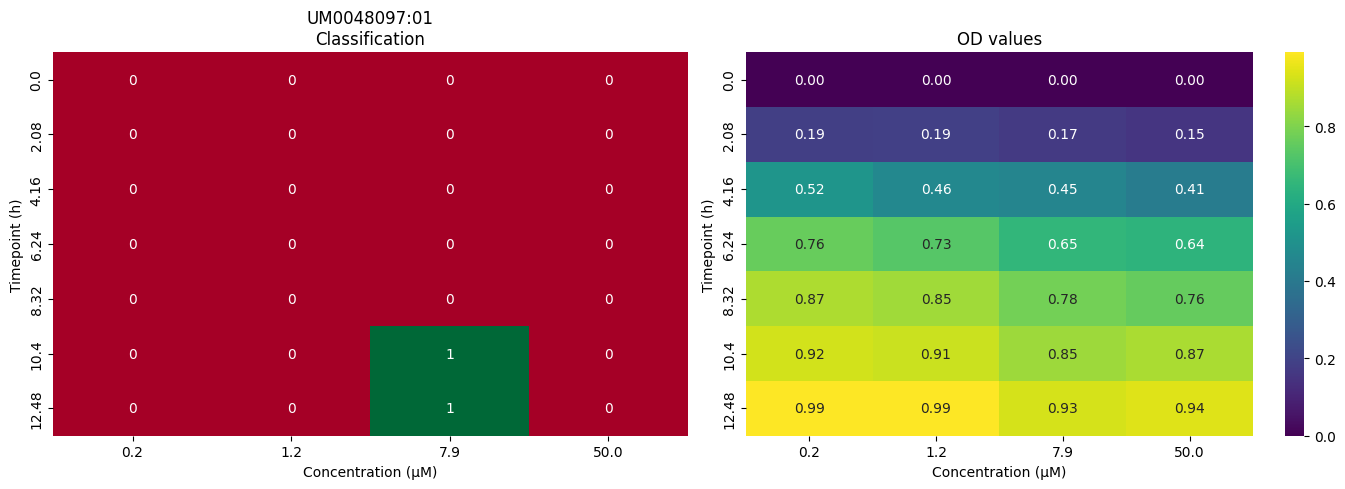

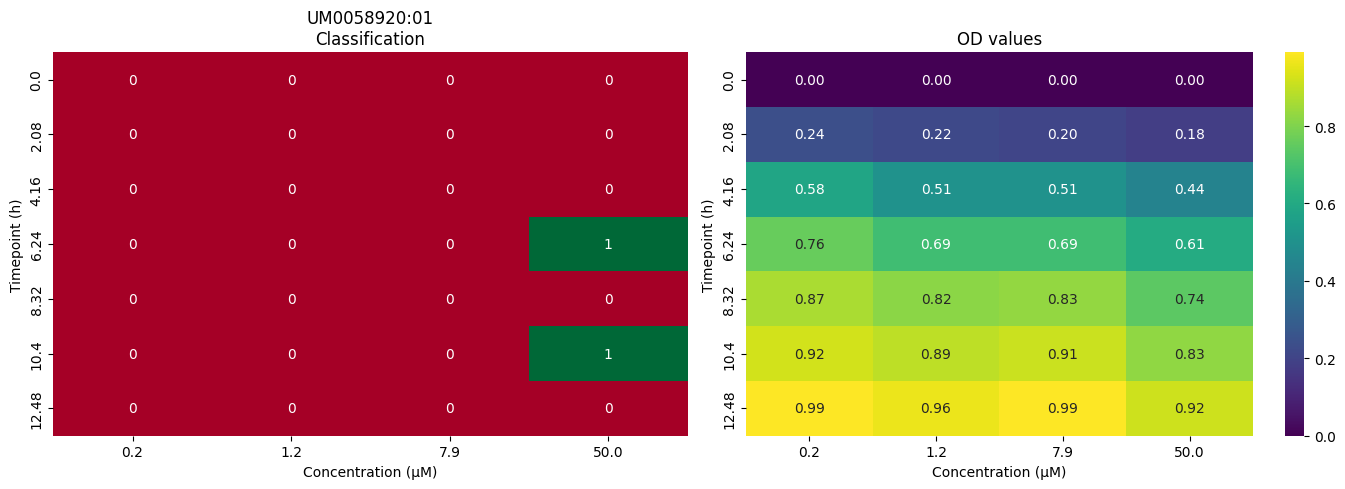

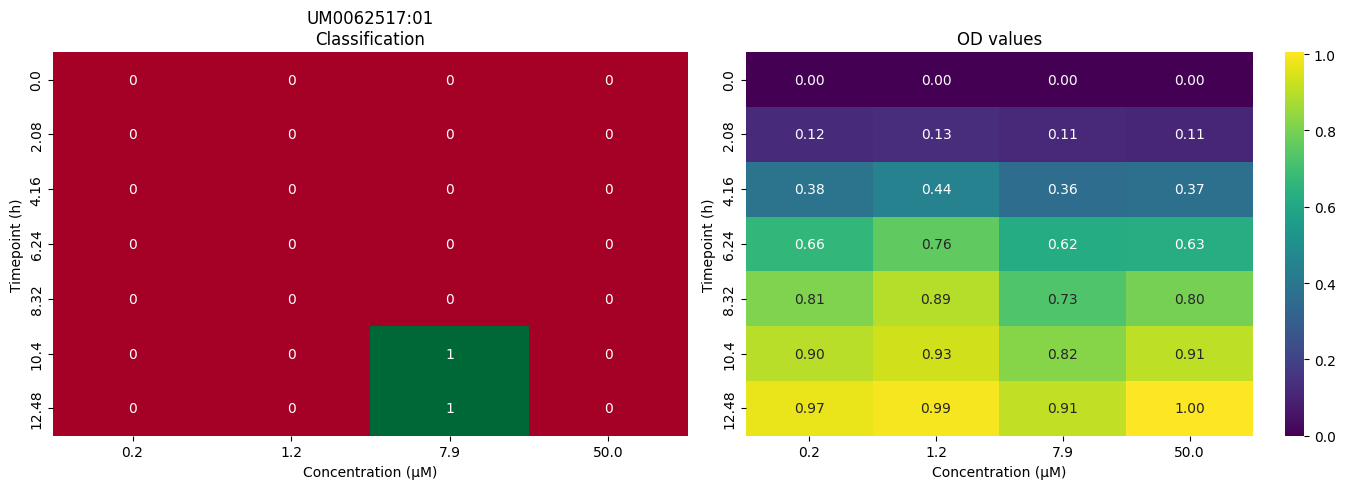

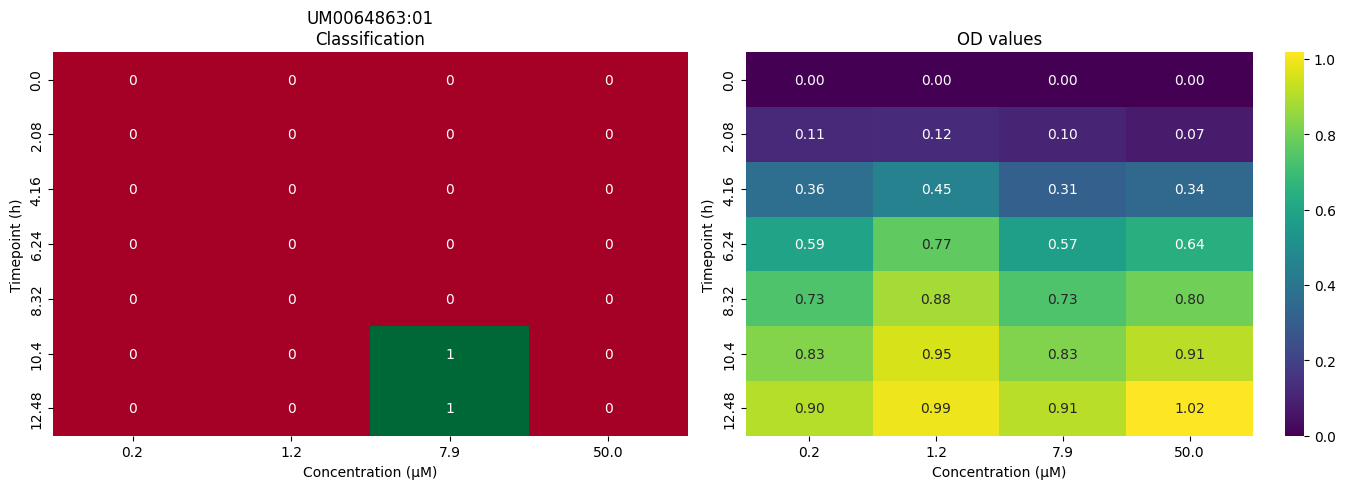

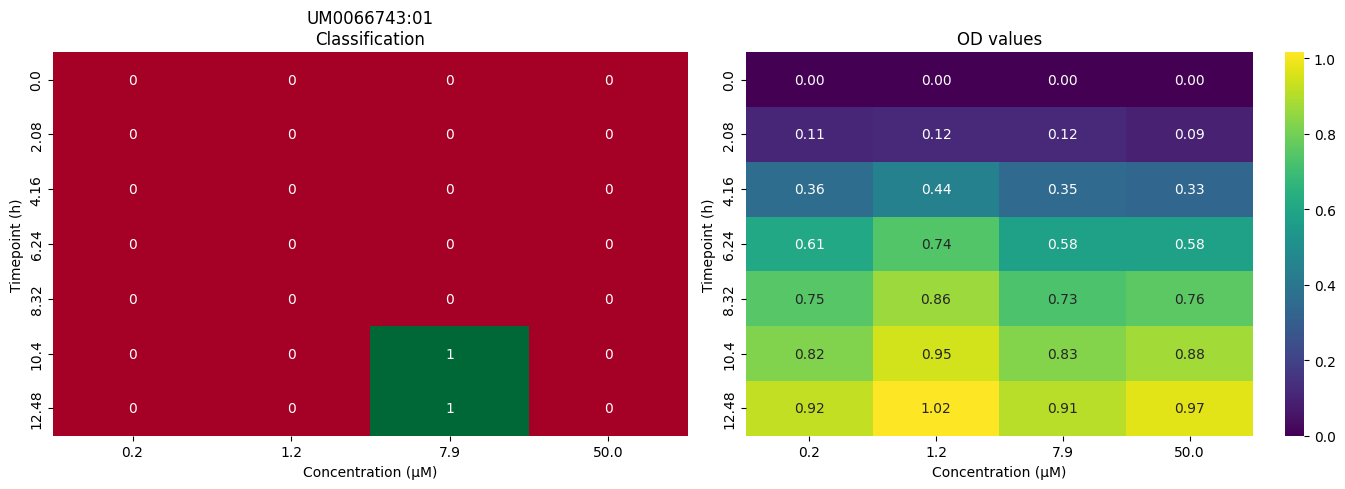

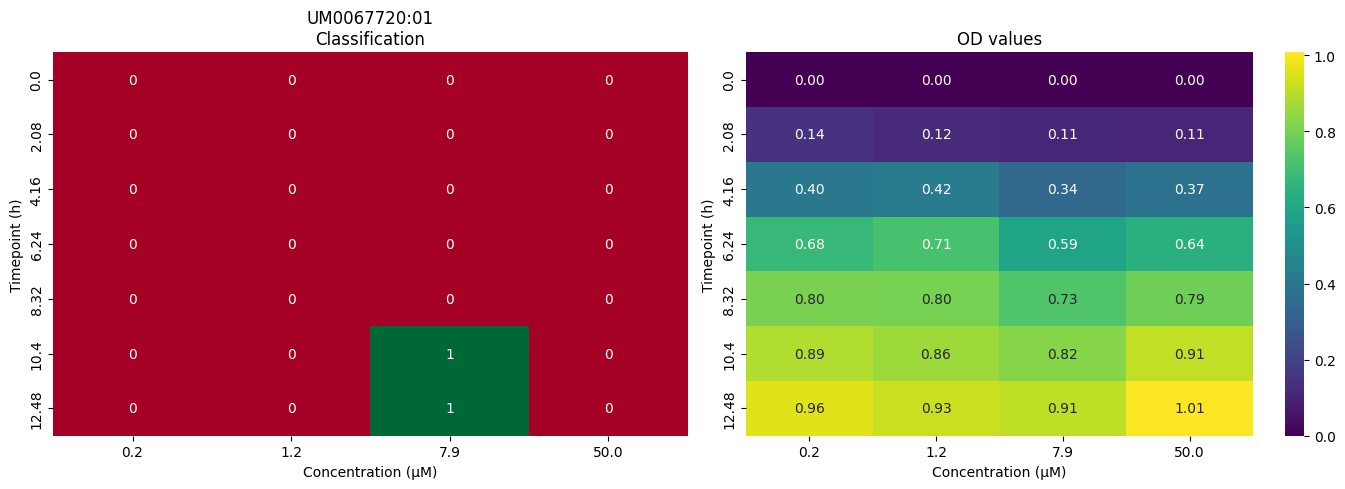

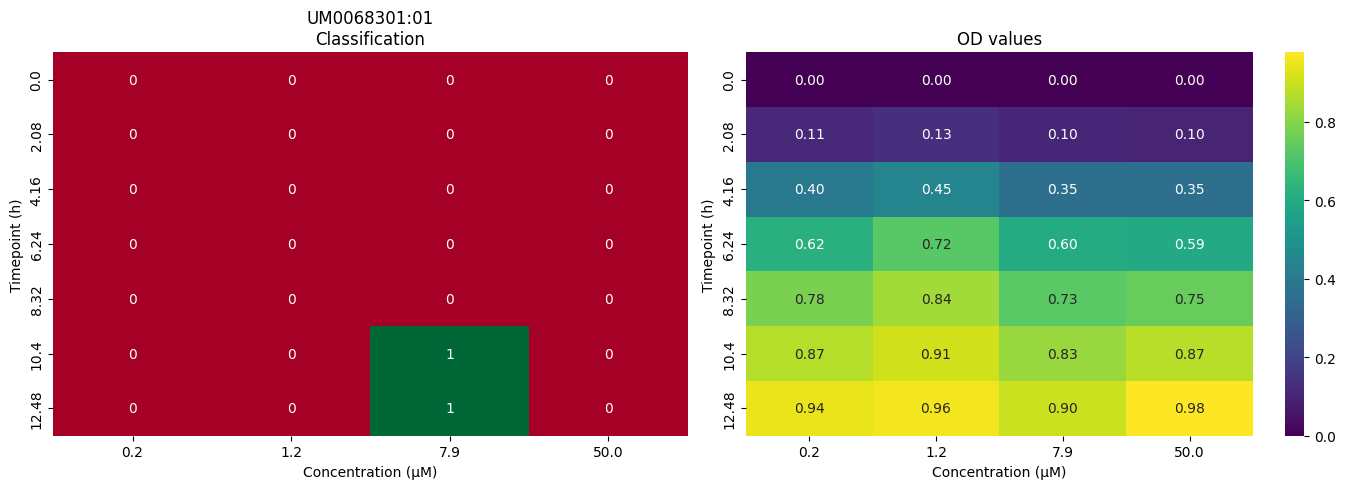

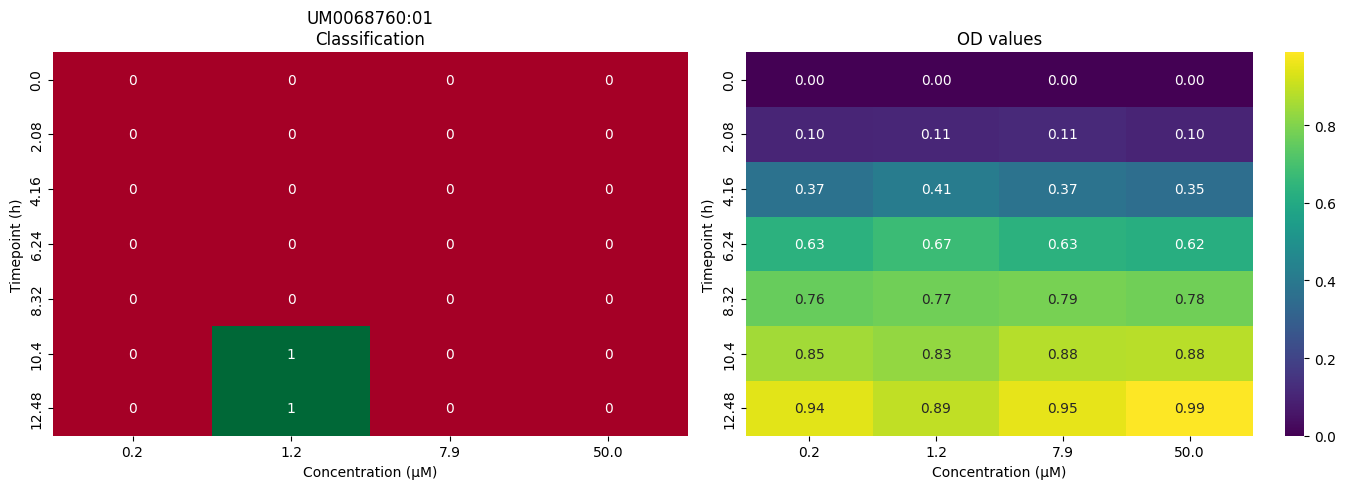

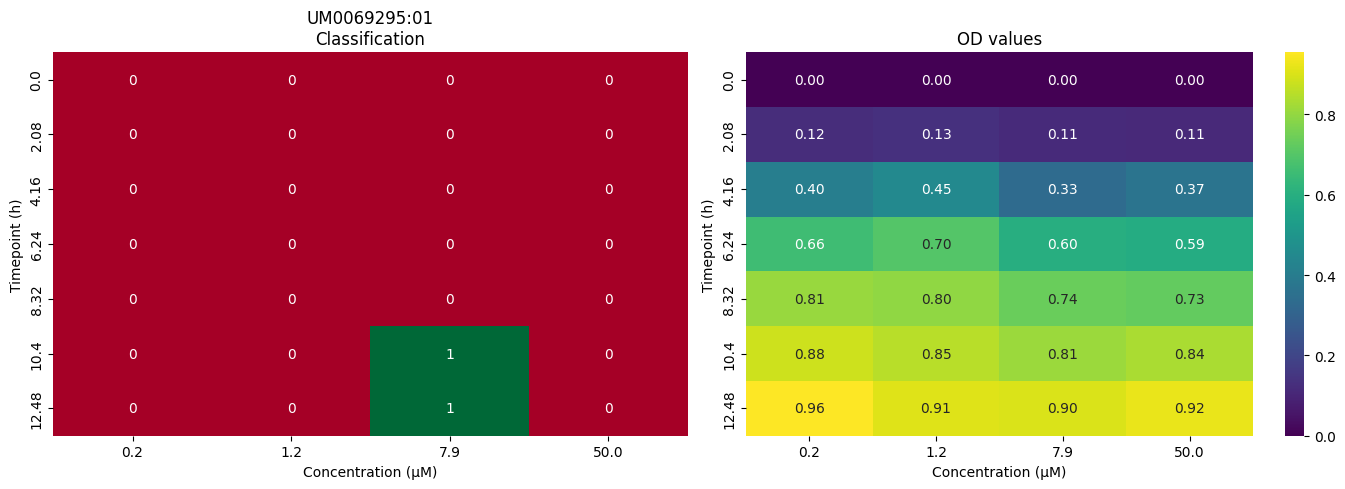

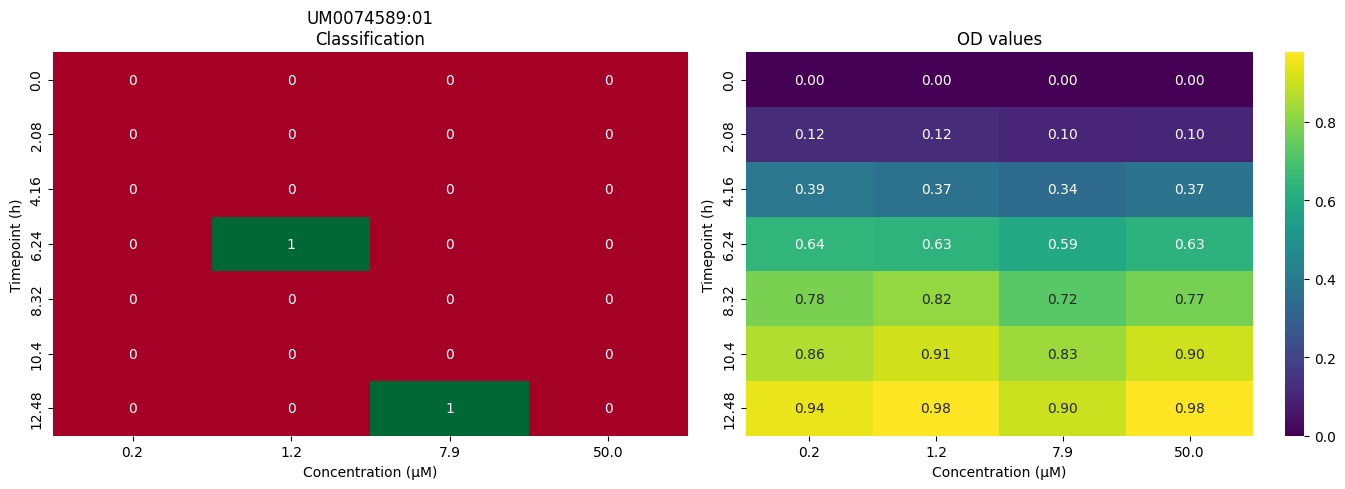

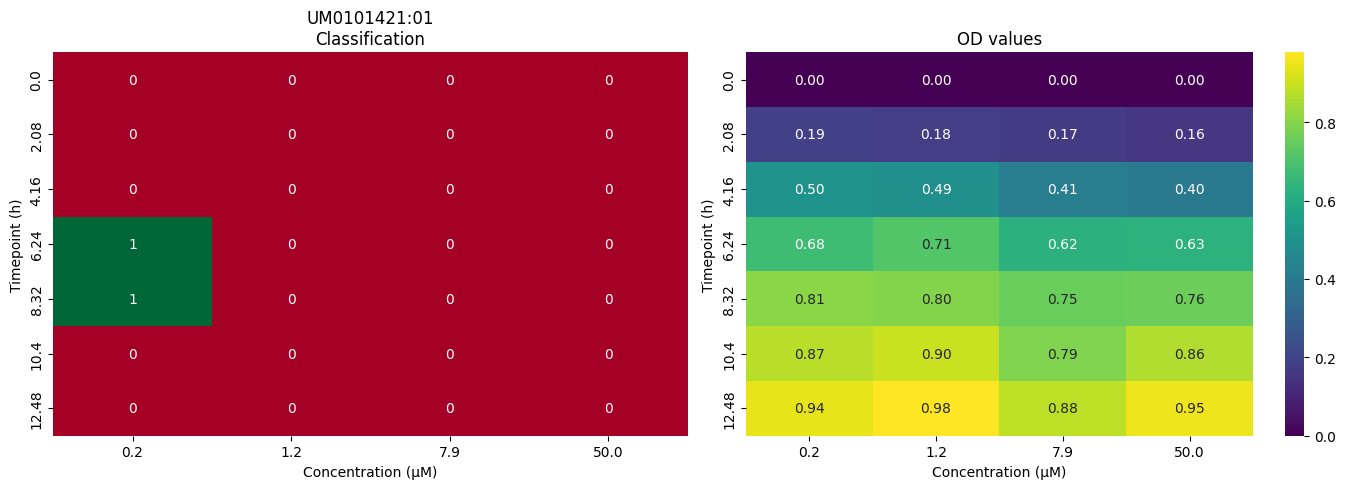

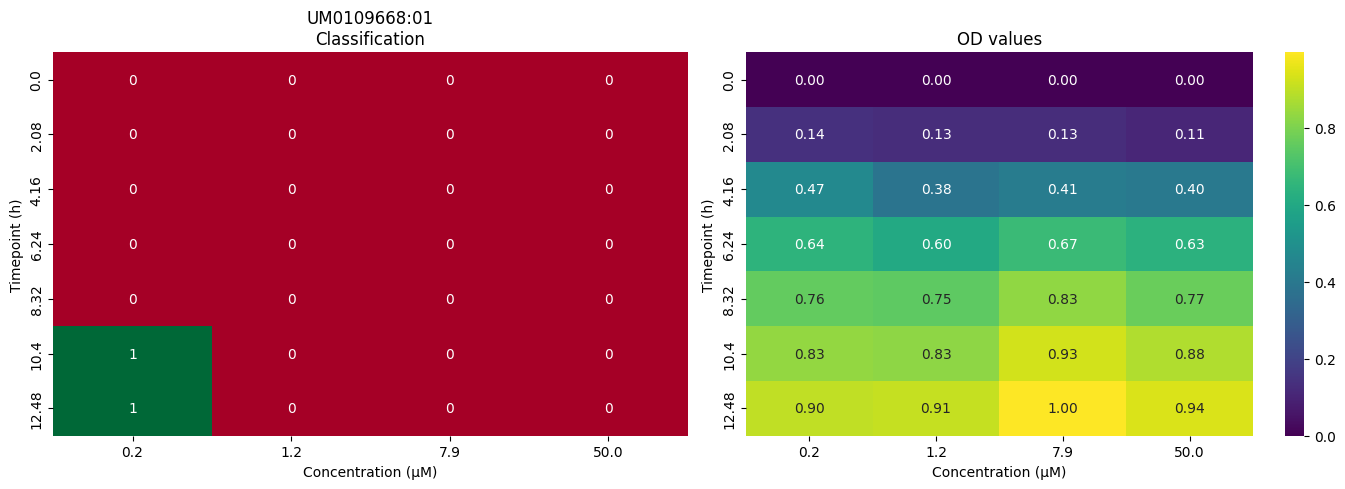

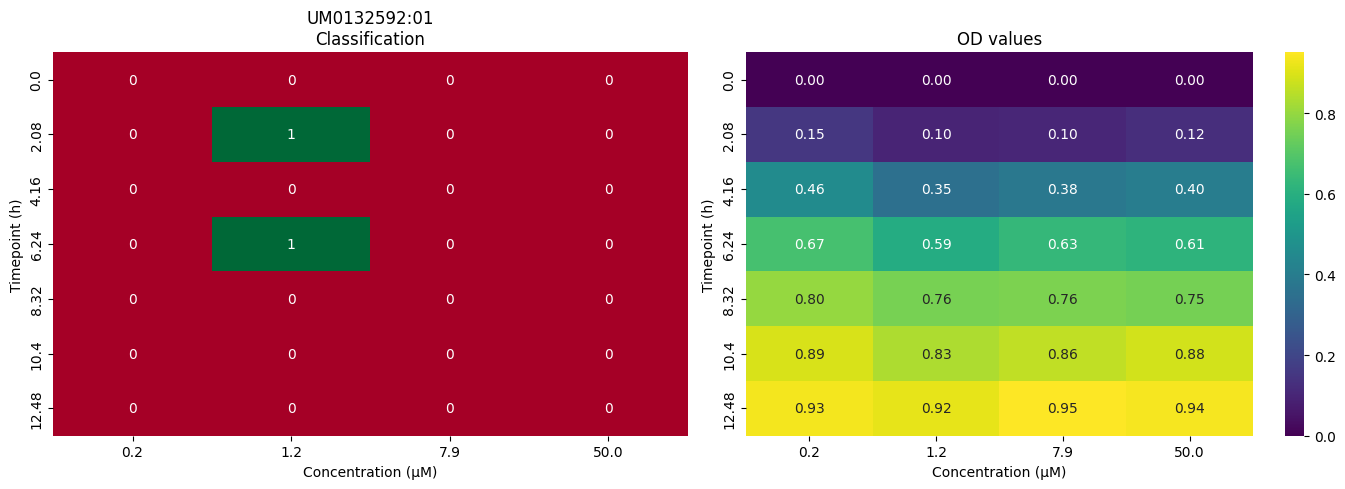

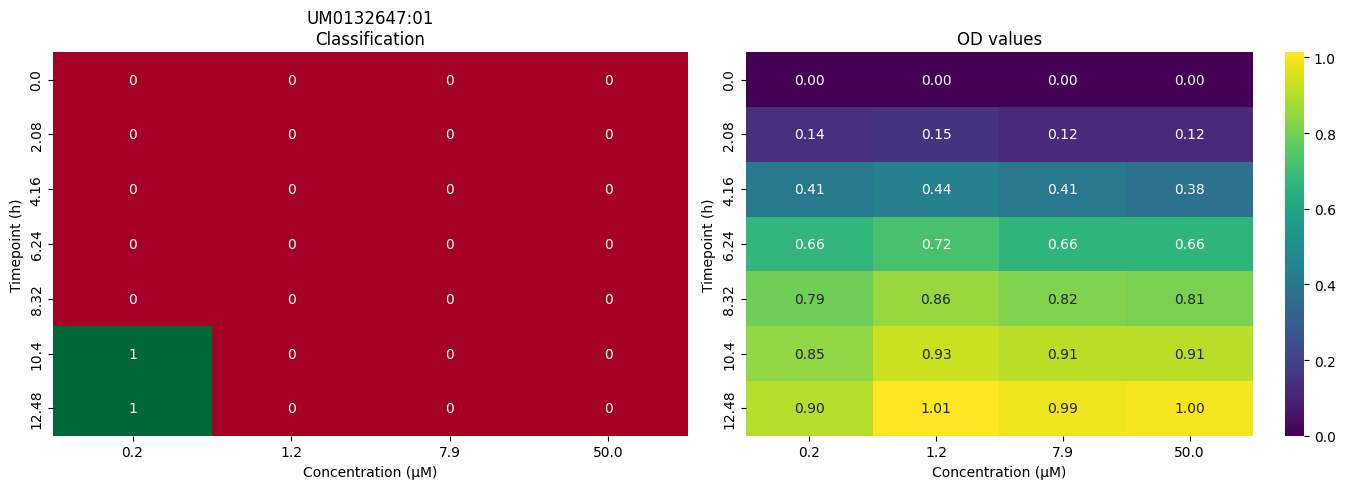

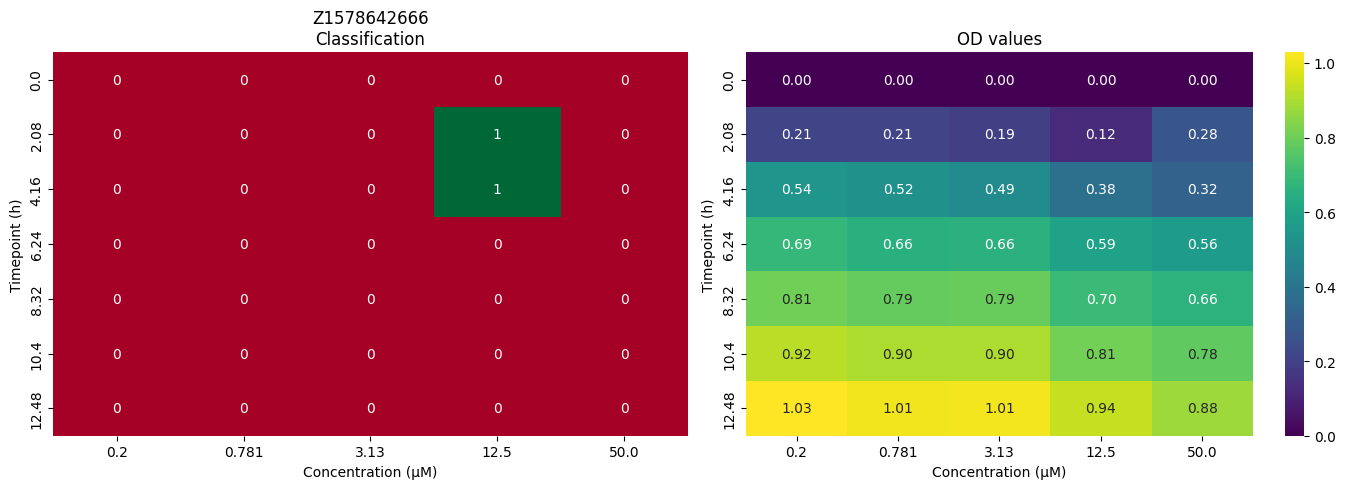

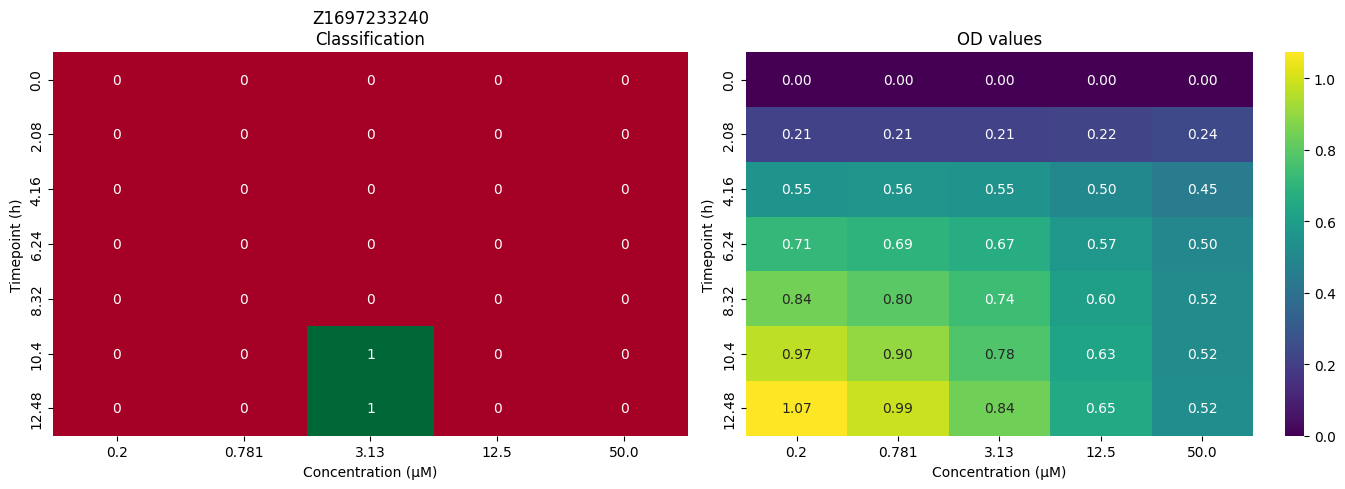

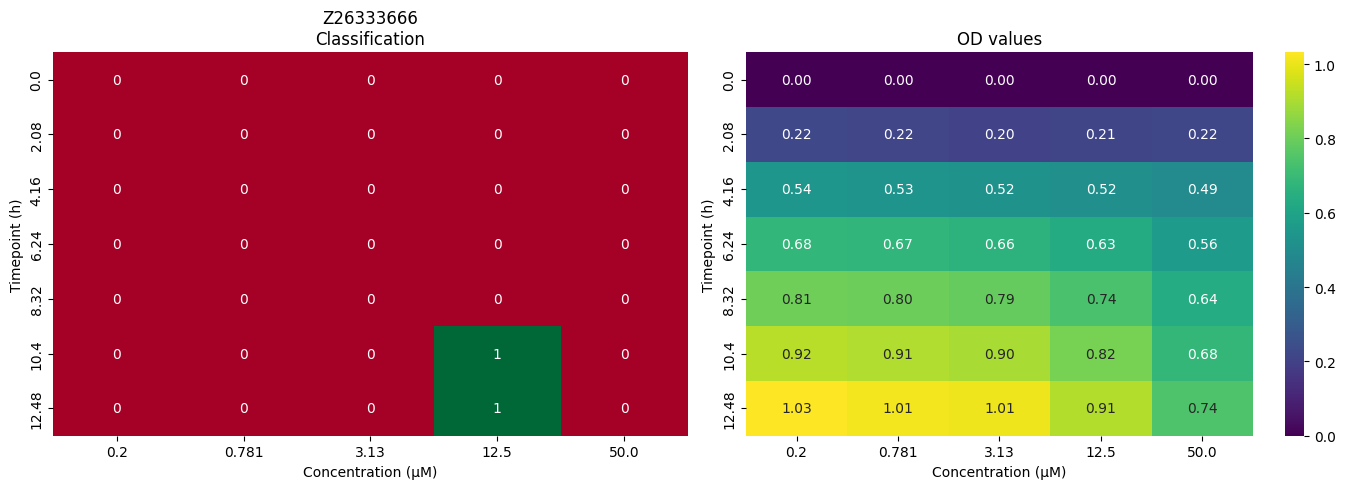

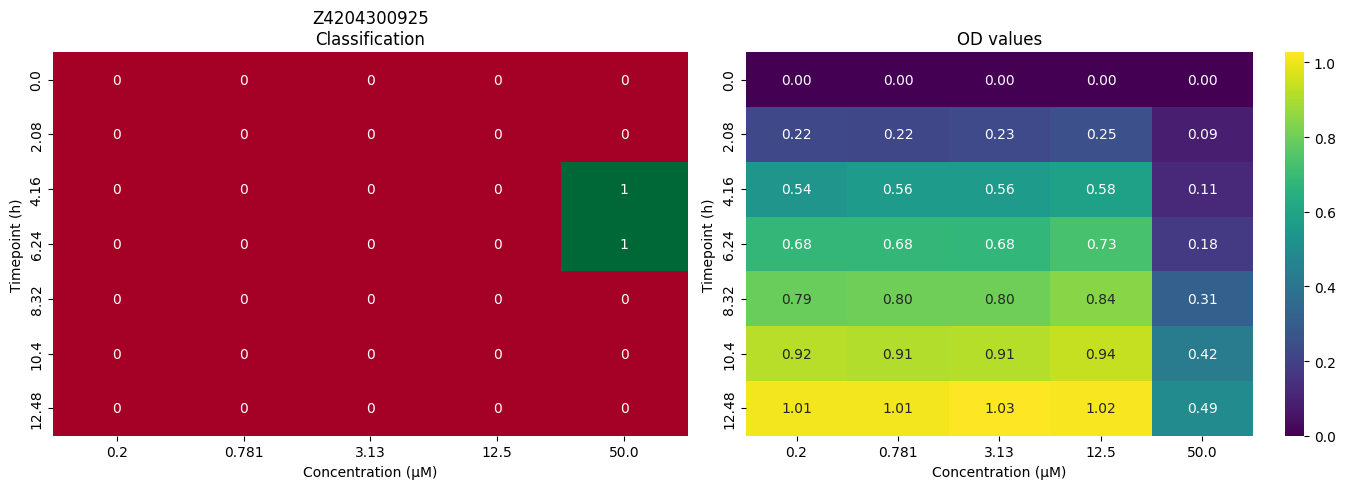

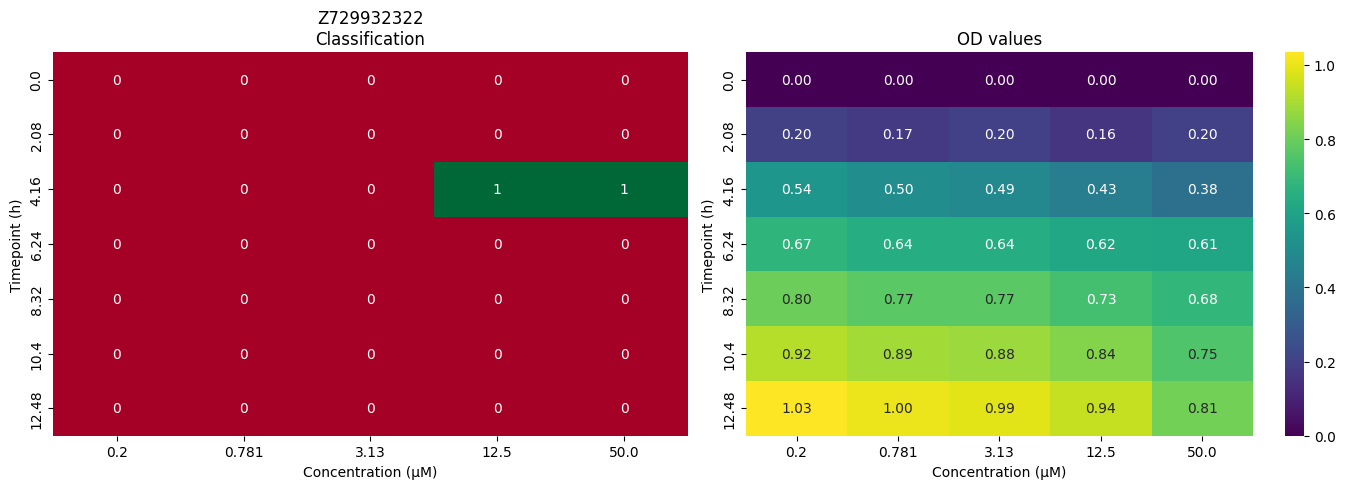

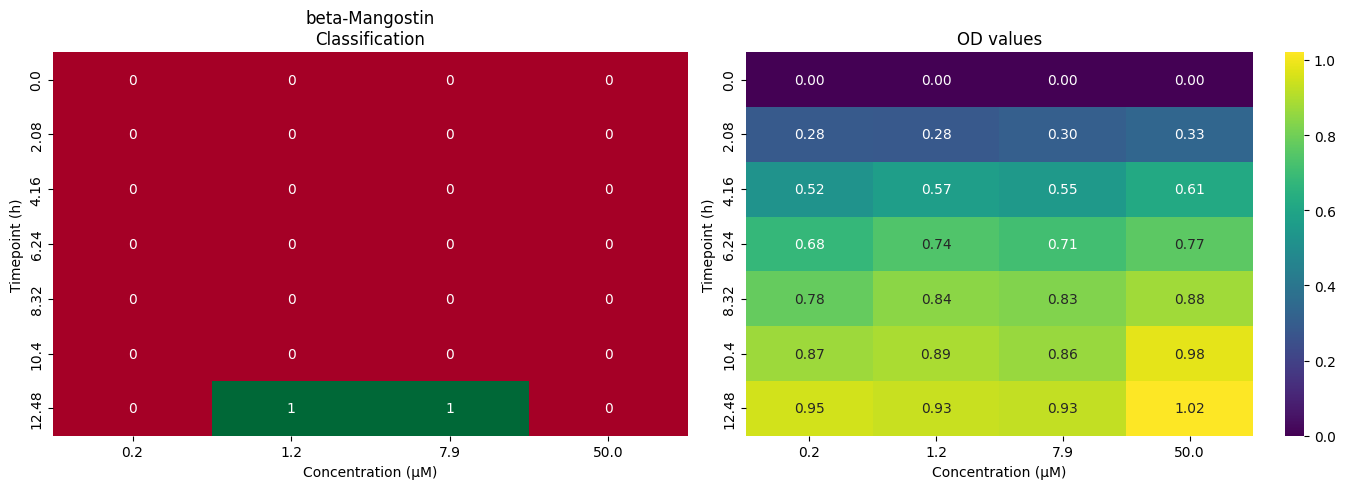

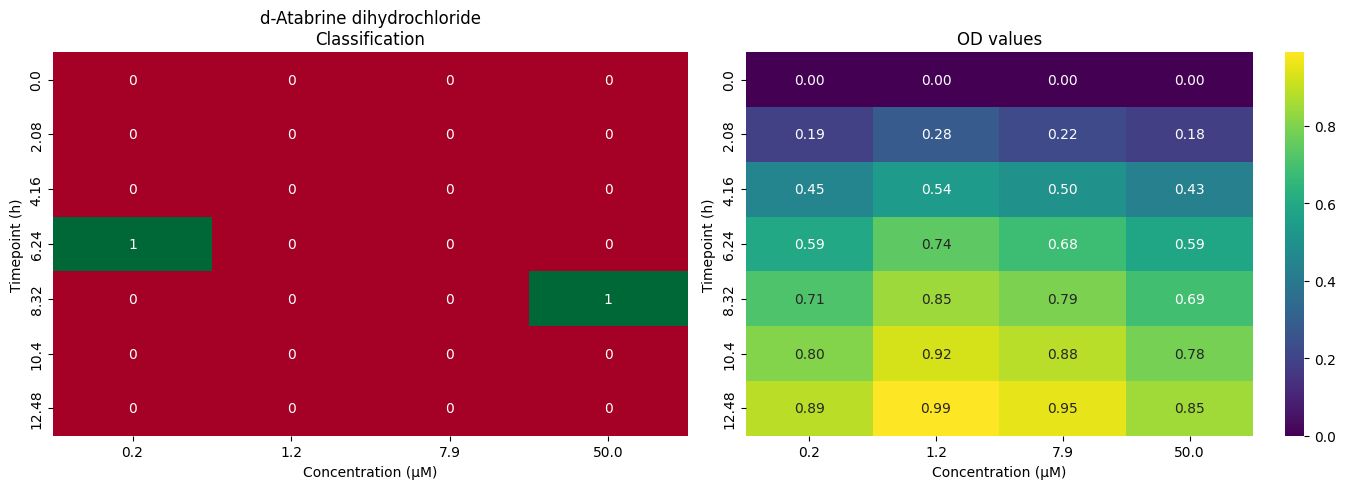

TOTAL: 49


In [19]:
tot=0
for n_active in [2]:        
      
                                                              
      cell_counts = defaultdict(int)                                                   
      compounds = []                                                                     
      for m in multi_conc:                                                               
          if (                                                                           
              bool(m.pivot_cls.values.any()) and            
              not (
                  (12.48 in m.pivot_cls.index) and                                       
                  (50.0 in m.pivot_cls.columns) and
                  (m.pivot_cls.loc[12.48, 50.0] == 1)                                    
              ) and                                                                      
              m.pivot_cls.values.sum() == n_active
          ):                                                                             
              compounds.append(m)                           

      for m in compounds:
             
          tot+=1                                                                 
          fig, axes = plt.subplots(1, 2, figsize=(14, 5))
                                                                                         
          sns.heatmap(m.pivot_cls.astype(float), annot=True, fmt='.0f',                  
                      cmap='RdYlGn', vmin=0, vmax=1, ax=axes[0], cbar=False)
          axes[0].set_title(f'{m.compound}\nClassification')                             
          axes[0].set_xlabel('Concentration (µM)')                                       
          axes[0].set_ylabel('Timepoint (h)')                                            
                                                                                         
          sns.heatmap(m.pivot_od.astype(float), annot=True, fmt='.2f',                   
                      cmap='viridis', ax=axes[1])
          axes[1].set_title('OD values')                                                 
          axes[1].set_xlabel('Concentration (µM)')                                       
          axes[1].set_ylabel('Timepoint (h)')
                                                                                         
          plt.tight_layout()                                
          plt.show()


print(f'TOTAL: {tot}')


In [38]:
outlier = [                                                                            
      m for m in multi_conc                                                            
      if m.pivot_cls.values.sum() >= 15 and not (                                        
          (12.48 in m.pivot_cls.index) and                                               
          (50.0 in m.pivot_cls.columns) and                                              
          (m.pivot_cls.loc[12.48, 50.0] == 1)                                            
      )
  ]   

for m in outlier:                                                                      
    print(sorted(float(c) for c in m.pivot_cls.columns))  

[0.2, 0.781, 3.13, 12.5, 50.0]


In [13]:
for n_active in [1]:                                                                
    compounds = [                                                                      
        m for m in multi_conc                                                          
        if m.pivot_cls.values.sum() == n_active and not (
            (12.48 in m.pivot_cls.index) and                                           
            (50.0 in m.pivot_cls.columns) and                                          
            (m.pivot_cls.loc[12.48, 50.0] == 1)                                        
        )                                                                              
    ]                                                                                  
    print(f'\n=== {n_active} active cells: {len(compounds)} compounds ===')            
    for m in compounds:
        fig, ax = plt.subplots(figsize=(8, 4))                                         
        sns.heatmap(m.pivot_cls.astype(float), annot=True, fmt='.0f',
                    cmap='RdYlGn', vmin=0, vmax=1, ax=ax, cbar=False)                  
        ax.set_title(m.compound)                          
        ax.set_xlabel('Concentration (µM)')                                            
        ax.set_ylabel('Timepoint (h)')                    
        plt.tight_layout()                                                             
        plt.show()  